In [1]:
import xarray as xr
import numpy as np

# Открываем drought данные которые уже есть
drought = xr.open_dataset("climate_risk_data/drought/CDD_C3S-glob-agric_hadgem2-es_rcp8p5_season_20410101-20701231_v1.0.nc")

# Проверяем покрытие — Южный Кавказ примерно 38-42°N, 40-50°E
caucasus = drought.CDD.sel(
    lat=slice(38, 42),
    lon=slice(40, 50)
)

print(f"✅ Данные для Южного Кавказа:")
print(f"Размер: {caucasus.shape}")
print(f"Широта: {float(caucasus.lat.min()):.1f} — {float(caucasus.lat.max()):.1f}")
print(f"Долгота: {float(caucasus.lon.min()):.1f} — {float(caucasus.lon.max()):.1f}")
print(f"Среднее CDD: {float(caucasus.mean()):.1f} дней")

✅ Данные для Южного Кавказа:
Размер: (119, 8, 20)
Широта: 38.2 — 41.8
Долгота: 40.2 — 49.8
Среднее CDD: 23.0 дней


In [2]:
import cdsapi
import os

os.makedirs("climate_risk_data/caucasus", exist_ok=True)

c = cdsapi.Client()

print("⏳ Скачиваем температурные данные ERA5-Land для Южного Кавказа...")
c.retrieve(
    'reanalysis-era5-land-monthly-means',
    {
        'product_type': 'monthly_averaged_reanalysis',
        'variable': '2m_temperature',
        'year': [str(y) for y in range(2010, 2024)],
        'month': ['06', '07', '08'],  # летние месяцы
        'time': '00:00',
        'area': [42, 40, 38, 50],  # Южный Кавказ [N, W, S, E]
        'format': 'netcdf'
    },
    'climate_risk_data/caucasus/temperature_caucasus.nc'
)
print("✅ Температурные данные скачаны!")

⏳ Скачиваем температурные данные ERA5-Land для Южного Кавказа...


2026-09-11 12:41:57,193 INFO Request ID is a4ca93b2-65a8-4928-a5d9-9338cd2ba3bb
2026-09-11 12:41:57,282 INFO status has been updated to accepted
2026-09-11 12:42:30,730 INFO status has been updated to running
2026-09-11 12:42:47,897 INFO status has been updated to successful


d5103b012e0e2a5059eb398237842c9a.zip:   0%|          | 0.00/308k [00:00<?, ?B/s]

✅ Температурные данные скачаны!


In [3]:
print("⏳ Скачиваем данные по населению...")
c.retrieve(
    'derived-gridded-population-estimates',
    {
        'format': 'zip',
        'variable': 'total_population',
        'year': '2020',
        'resolution': '30_arc_seconds'
    },
    'climate_risk_data/caucasus/population_caucasus.zip'
)
print("✅ Данные по населению скачаны!")

⏳ Скачиваем данные по населению...


HTTPError: 404 Client Error: Not Found for url: https://cds.climate.copernicus.eu/api/retrieve/v1/processes/derived-gridded-population-estimates
process not found
dataset derived-gridded-population-estimates not found

In [4]:
import xarray as xr
import numpy as np

# Открываем температурные данные
temp = xr.open_dataset("climate_risk_data/caucasus/temperature_caucasus.nc")
print("📊 Структура температурных данных:")
print(temp)
print()
print("📅 Переменные:", list(temp.data_vars))

# Конвертируем из Кельвинов в Цельсий
t2m = temp['t2m'] - 273.15
print(f"\n🌡️ Температура (°C):")
print(f"Минимум: {float(t2m.min()):.1f}°C")
print(f"Максимум: {float(t2m.max()):.1f}°C")
print(f"Среднее лето: {float(t2m.mean()):.1f}°C")

ValueError: did not find a match in any of xarray's currently installed IO backends ['netcdf4']. Consider explicitly selecting one of the installed engines via the ``engine`` parameter, or installing additional IO dependencies, see:
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
https://docs.xarray.dev/en/stable/user-guide/io.html

In [5]:
import os

# Ищем файл температуры
print("📁 Содержимое climate_risk_data/caucasus:")
caucasus_path = "climate_risk_data/caucasus"
if os.path.exists(caucasus_path):
    for f in os.listdir(caucasus_path):
        size_mb = os.path.getsize(os.path.join(caucasus_path, f)) / (1024*1024)
        print(f" — {f} ({size_mb:.1f} MB)")
else:
    print("❌ Папка не найдена")

print()
print("📁 Текущая папка:")
print(os.getcwd())

📁 Содержимое climate_risk_data/caucasus:
 — temperature_caucasus.nc (0.3 MB)

📁 Текущая папка:
C:\Users\Galiya


In [6]:
import os

# Ищем файл температуры в домашней папке
print("📁 Ищем файл температуры:")
for root, dirs, files in os.walk("C:/Users/Galiya/climate_risk_data"):
    for f in files:
        full_path = os.path.join(root, f)
        size_mb = os.path.getsize(full_path) / (1024*1024)
        print(f" — {full_path} ({size_mb:.1f} MB)")

📁 Ищем файл температуры:
 — C:/Users/Galiya/climate_risk_data\drought_cdd_europe.zip (19.5 MB)
 — C:/Users/Galiya/climate_risk_data\flood_cwd_europe.zip (3.0 MB)
 — C:/Users/Galiya/climate_risk_data\caucasus\temperature_caucasus.nc (0.3 MB)
 — C:/Users/Galiya/climate_risk_data\drought\CDD_C3S-glob-agric_hadgem2-es_rcp8p5_season_20110101-20401231_v1.0.nc (6.6 MB)
 — C:/Users/Galiya/climate_risk_data\drought\CDD_C3S-glob-agric_hadgem2-es_rcp8p5_season_20410101-20701231_v1.0.nc (6.6 MB)
 — C:/Users/Galiya/climate_risk_data\drought\CDD_C3S-glob-agric_hadgem2-es_rcp8p5_season_20710101-20991231_v1.0.nc (6.3 MB)
 — C:/Users/Galiya/climate_risk_data\flood\number-of-consecutive-wet-days_europe_era5_yearly_2010_v1.nc (0.3 MB)
 — C:/Users/Galiya/climate_risk_data\flood\number-of-consecutive-wet-days_europe_era5_yearly_2011_v1.nc (0.3 MB)
 — C:/Users/Galiya/climate_risk_data\flood\number-of-consecutive-wet-days_europe_era5_yearly_2012_v1.nc (0.3 MB)
 — C:/Users/Galiya/climate_risk_data\flood\numbe

In [7]:
import xarray as xr
import numpy as np

# Открываем температурные данные с полным путём
temp = xr.open_dataset("C:/Users/Galiya/climate_risk_data/caucasus/temperature_caucasus.nc")
print("📊 Структура температурных данных:")
print(temp)
print()
print("📅 Переменные:", list(temp.data_vars))

# Конвертируем из Кельвинов в Цельсий
t2m = temp['t2m'] - 273.15
print(f"\n🌡️ Температура (°C):")
print(f"Минимум: {float(t2m.min()):.1f}°C")
print(f"Максимум: {float(t2m.max()):.1f}°C")
print(f"Среднее лето: {float(t2m.mean()):.1f}°C")


ValueError: did not find a match in any of xarray's currently installed IO backends ['netcdf4']. Consider explicitly selecting one of the installed engines via the ``engine`` parameter, or installing additional IO dependencies, see:
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
https://docs.xarray.dev/en/stable/user-guide/io.html

In [8]:
import xarray as xr
import numpy as np

# Открываем с явным указанием engine
temp = xr.open_dataset(
    "C:/Users/Galiya/climate_risk_data/caucasus/temperature_caucasus.nc",
    engine='netcdf4'
)
print("📊 Структура температурных данных:")
print(temp)
print()
print("📅 Переменные:", list(temp.data_vars))

OSError: [Errno -51] NetCDF: Unknown file format: 'C:\\Users\\Galiya\\climate_risk_data\\caucasus\\temperature_caucasus.nc'

In [9]:
import os

# Проверяем первые байты файла чтобы понять формат
with open("C:/Users/Galiya/climate_risk_data/caucasus/temperature_caucasus.nc", 'rb') as f:
    header = f.read(4)
    print(f"Первые байты: {header}")
    print(f"Hex: {header.hex()}")

Первые байты: b'PK\x03\x04'
Hex: 504b0304


In [10]:
import zipfile
import os

# Переименовываем и разархивируем
zip_path = "C:/Users/Galiya/climate_risk_data/caucasus/temperature_caucasus.nc"
extract_path = "C:/Users/Galiya/climate_risk_data/caucasus/"

# Переименовываем в .zip
zip_renamed = "C:/Users/Galiya/climate_risk_data/caucasus/temperature_caucasus.zip"
os.rename(zip_path, zip_renamed)

# Разархивируем
with zipfile.ZipFile(zip_renamed, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("📁 Файлы после разархивирования:")
for f in os.listdir(extract_path):
    size_mb = os.path.getsize(os.path.join(extract_path, f)) / (1024*1024)
    print(f" — {f} ({size_mb:.1f} MB)")

📁 Файлы после разархивирования:
 — data_stream-moda.nc (0.3 MB)
 — temperature_caucasus.zip (0.3 MB)


In [11]:
import xarray as xr
import numpy as np

# Открываем правильный файл
temp = xr.open_dataset(
    "C:/Users/Galiya/climate_risk_data/caucasus/data_stream-moda.nc",
    engine='netcdf4'
)
print("📊 Структура температурных данных:")
print(temp)
print()
print("📅 Переменные:", list(temp.data_vars))

# Конвертируем из Кельвинов в Цельсий
t2m = temp['t2m'] - 273.15
print(f"\n🌡️ Температура (°C):")
print(f"Минимум: {float(t2m.min()):.1f}°C")
print(f"Максимум: {float(t2m.max()):.1f}°C")
print(f"Среднее лето: {float(t2m.mean()):.1f}°C")

📊 Структура температурных данных:
<xarray.Dataset> Size: 698kB
Dimensions:     (valid_time: 42, latitude: 41, longitude: 101)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 336B 2010-06-01 ... 2023-08-01
    expver      (valid_time) <U4 672B ...
  * latitude    (latitude) float64 328B 42.0 41.9 41.8 41.7 ... 38.2 38.1 38.0
  * longitude   (longitude) float64 808B 40.0 40.1 40.2 40.3 ... 49.8 49.9 50.0
    number      int64 8B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 696kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-11T10:42 GRIB to CDM+CF via cfgrib-0.9.1...

📅 Переменные: ['t2m']

🌡️ Температура (°C):
Минимум: 5.0°C
Максимум: 33.5°C
Среднее лето: 21.0°C


In [12]:
import xarray as xr
import numpy as np

# Открываем drought данные — период 2041-2070
drought = xr.open_dataset(
    "C:/Users/Galiya/climate_risk_data/drought/CDD_C3S-glob-agric_hadgem2-es_rcp8p5_season_20410101-20701231_v1.0.nc"
)

# Выбираем летний сезон и регион Южного Кавказа
drought_caucasus = drought.CDD.sel(
    time=drought.time.dt.month == 7,
    lat=slice(38, 42),
    lon=slice(40, 50)
).mean(dim='time')

print(f"✅ Drought данные для Кавказа:")
print(f"Размер: {drought_caucasus.shape}")
print(f"Среднее CDD: {float(drought_caucasus.mean()):.1f} дней")
print(f"Максимум CDD: {float(drought_caucasus.max()):.1f} дней")
print(f"Минимум CDD: {float(drought_caucasus.min()):.1f} дней")

✅ Drought данные для Кавказа:
Размер: (8, 20)
Среднее CDD: 41.3 дней
Максимум CDD: 82.6 дней
Минимум CDD: 6.2 дней


In [13]:
# Средняя летняя температура по трём странам
countries = {
    'Грузия':      {'lat': slice(41, 42), 'lon': slice(40, 47)},
    'Армения':     {'lat': slice(38, 41), 'lon': slice(43, 47)},
    'Азербайджан': {'lat': slice(38, 42), 'lon': slice(45, 50)},
}

print("🌡️ Средняя летняя температура 2010-2023 (°C):")
for country, coords in countries.items():
    subset = t2m.sel(
        latitude=coords['lat'],
        longitude=coords['lon']
    ).mean()
    print(f" — {country}: {float(subset):.1f}°C")

print()
print("🏜️ Среднее CDD 2041-2070 (дней без осадков):")
for country, coords in countries.items():
    subset = drought_caucasus.sel(
        lat=coords['lat'],
        lon=coords['lon']
    ).mean()
    print(f" — {country}: {float(subset):.1f} дней")

🌡️ Средняя летняя температура 2010-2023 (°C):
 — Грузия: nan°C
 — Армения: nan°C
 — Азербайджан: nan°C

🏜️ Среднее CDD 2041-2070 (дней без осадков):
 — Грузия: 21.0 дней
 — Армения: 43.2 дней
 — Азербайджан: 46.9 дней


In [14]:
# Проверим точные координаты температурных данных
print("Latitude values:", temp.latitude.values)
print("Longitude values:", temp.longitude.values[:5], "...", temp.longitude.values[-5:])

Latitude values: [42.  41.9 41.8 41.7 41.6 41.5 41.4 41.3 41.2 41.1 41.  40.9 40.8 40.7
 40.6 40.5 40.4 40.3 40.2 40.1 40.  39.9 39.8 39.7 39.6 39.5 39.4 39.3
 39.2 39.1 39.  38.9 38.8 38.7 38.6 38.5 38.4 38.3 38.2 38.1 38. ]
Longitude values: [40.  40.1 40.2 40.3 40.4] ... [49.6 49.7 49.8 49.9 50. ]


In [15]:
# Средняя летняя температура по трём странам — правильные координаты
countries_temp = {
    'Грузия':      {'latitude': slice(42, 41), 'longitude': slice(40, 47)},
    'Армения':     {'latitude': slice(41, 38), 'longitude': slice(43, 47)},
    'Азербайджан': {'latitude': slice(42, 38), 'longitude': slice(45, 50)},
}

print("🌡️ Средняя летняя температура 2010-2023 (°C):")
for country, coords in countries_temp.items():
    subset = t2m.sel(
        latitude=coords['latitude'],
        longitude=coords['longitude']
    ).mean()
    print(f" — {country}: {float(subset):.1f}°C")

🌡️ Средняя летняя температура 2010-2023 (°C):
 — Грузия: 19.3°C
 — Армения: 19.6°C
 — Азербайджан: 22.7°C


In [16]:
import os
import zipfile

# Найдём файл населения — где он скачался?
print("📁 Ищем файл населения в Downloads:")
downloads = "C:/Users/Galiya/Downloads"
for f in os.listdir(downloads):
    if 'GHS' in f or 'pop' in f.lower() or 'population' in f.lower():
        size_mb = os.path.getsize(os.path.join(downloads, f)) / (1024*1024)
        print(f" — {f} ({size_mb:.1f} MB)")

📁 Ищем файл населения в Downloads:
 — COLOR_POP.jpg (2.0 MB)
 — POP_GRID_2024_3035.shp.zip (4.3 MB)
 — ToR Regional report on population exposure to climate hazards.docx (0.2 MB)


In [17]:
import zipfile
import shutil
import os

# Разархивируем
zip_path = "C:/Users/Galiya/Downloads/POP_GRID_2024_3035.shp.zip"
extract_path = "C:/Users/Galiya/climate_risk_data/caucasus/population"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("📁 Файлы по населению:")
for f in os.listdir(extract_path):
    size_mb = os.path.getsize(os.path.join(extract_path, f)) / (1024*1024)
    print(f" — {f} ({size_mb:.1f} MB)")

📁 Файлы по населению:
 — POP_GRID_2024_3035.shp (0.0 MB)


In [18]:
import cdsapi
import os

c = cdsapi.Client()

print("⏳ Скачиваем данные по населению...")
c.retrieve(
    'derived-gridded-population-estimates',
    {
        'format': 'zip',
        'variable': 'total_population',
        'year': '2020',
        'version': '1_0',
    },
    'C:/Users/Galiya/climate_risk_data/caucasus/population_2020.zip'
)
print("✅ Данные по населению скачаны!")

⏳ Скачиваем данные по населению...


HTTPError: 404 Client Error: Not Found for url: https://cds.climate.copernicus.eu/api/retrieve/v1/processes/derived-gridded-population-estimates
process not found
dataset derived-gridded-population-estimates not found

In [19]:
import pandas as pd
import numpy as np

# Данные по населению по регионам Южного Кавказа
# Источник: World Bank 2020
population_data = {
    'Страна': ['Грузия', 'Армения', 'Азербайджан'],
    'Население_млн': [3.7, 3.0, 10.1],
    'Плотность_чел_км2': [53, 101, 120],
    'Городское_население_%': [59, 63, 56],
    'Летняя_температура_C': [19.3, 19.6, 22.7],
    'Засуха_CDD_дней': [21.0, 43.2, 46.9],
}

df = pd.DataFrame(population_data)

# Рассчитываем composite risk score
# Нормализуем каждый индикатор от 0 до 1
df['temp_norm'] = (df['Летняя_температура_C'] - df['Летняя_температура_C'].min()) / \
                  (df['Летняя_температура_C'].max() - df['Летняя_температура_C'].min())

df['drought_norm'] = (df['Засуха_CDD_дней'] - df['Засуха_CDD_дней'].min()) / \
                     (df['Засуха_CDD_дней'].max() - df['Засуха_CDD_дней'].min())

df['density_norm'] = (df['Плотность_чел_км2'] - df['Плотность_чел_км2'].min()) / \
                     (df['Плотность_чел_км2'].max() - df['Плотность_чел_км2'].min())

# Composite exposure score = среднее трёх нормализованных индикаторов
df['exposure_score'] = (df['temp_norm'] + df['drought_norm'] + df['density_norm']) / 3

print("📊 Климатический риск и население — Южный Кавказ:")
print(df[['Страна', 'Население_млн', 'Плотность_чел_км2', 
          'Летняя_температура_C', 'Засуха_CDD_дней', 'exposure_score']].to_string(index=False))

📊 Климатический риск и население — Южный Кавказ:
     Страна  Население_млн  Плотность_чел_км2  Летняя_температура_C  Засуха_CDD_дней  exposure_score
     Грузия            3.7                 53                  19.3             21.0        0.000000
    Армения            3.0                101                  19.6             43.2        0.553932
Азербайджан           10.1                120                  22.7             46.9        1.000000


In [20]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(20, 14))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.3)

# ── КАРТА 1: ТЕМПЕРАТУРА ──
ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
t2m_mean = t2m.mean(dim='valid_time')
im1 = ax1.pcolormesh(temp.longitude, temp.latitude, t2m_mean,
                      transform=ccrs.PlateCarree(),
                      cmap='YlOrRd', vmin=5, vmax=35)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax1.add_feature(cfeature.BORDERS, linewidth=0.8, color='gray')
ax1.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax1.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax1.set_extent([40, 50, 38, 42], crs=ccrs.PlateCarree())
ax1.set_title('Mean Summer Temperature\n2010-2023 (ERA5)', 
              fontsize=11, fontweight='bold')
plt.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.8,
             label='°C')

# ── КАРТА 2: ЗАСУХА ──
ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
im2 = ax2.pcolormesh(drought_caucasus.lon, drought_caucasus.lat, drought_caucasus,
                      transform=ccrs.PlateCarree(),
                      cmap='YlOrBr', vmin=0, vmax=90)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax2.add_feature(cfeature.BORDERS, linewidth=0.8, color='gray')
ax2.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax2.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax2.set_extent([40, 50, 38, 42], crs=ccrs.PlateCarree())
ax2.set_title('Drought Risk\nMax consecutive dry days 2041-2070 (RCP 8.5)',
              fontsize=11, fontweight='bold')
plt.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.8,
             label='Consecutive dry days')

# ── КАРТА 3: EXPOSURE SCORE ──
ax3 = fig.add_subplot(gs[0, 2])
countries_list = df['Страна'].tolist()
scores = df['exposure_score'].tolist()
colors = ['#1D9E75', '#F0997B', '#D85A30']
bars = ax3.barh(countries_list, scores, color=colors, edgecolor='white')
ax3.set_xlim(0, 1.2)
ax3.set_xlabel('Composite

SyntaxError: unterminated string literal (detected at line 48) (2208544202.py, line 48)

In [21]:
ax3.set_xlabel('Composite Exposure Score', fontsize=10)
ax3.set_title('Composite Climate Exposure Score', fontsize=11, fontweight='bold')

NameError: name 'ax3' is not defined

In [22]:
ax3.set_xlabel('Composite Exposure Score', fontsize=10)
ax3.set_title('Composite Climate Exposure Score', fontsize=11, fontweight='bold')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(20, 14))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.3)

# КАРТА 1: ТЕМПЕРАТУРА
ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
t2m_mean = t2m.mean(dim='valid_time')
im1 = ax1.pcolormesh(temp.longitude, temp.latitude, t2m_mean, transform=ccrs.PlateCarree(), cmap='YlOrRd', vmin=5, vmax=35)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax1.add_feature(cfeature.BORDERS, linewidth=0.8, color='gray')
ax1.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax1.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax1.set_extent([40, 50, 38, 42], crs=ccrs.PlateCarree())
ax1.set_title('Mean Summer Temperature\n2010-2023 (ERA5)', fontsize=11, fontweight='bold')
plt.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.8, label='Celsius')

# КАРТА 2: ЗАСУХА
ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
im2 = ax2.pcolormesh(drought_caucasus.lon, drought_caucasus.lat, drought_caucasus, transform=ccrs.PlateCarree(), cmap='YlOrBr', vmin=0, vmax=90)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax2.add_feature(cfeature.BORDERS, linewidth=0.8, color='gray')
ax2.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax2.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax2.set_extent([40, 50, 38, 42], crs=ccrs.PlateCarree())
ax2.set_title('Drought Risk\nMax consecutive dry days 2041-2070 (RCP 8.5)', fontsize=11, fontweight='bold')
plt.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.8, label='Consecutive dry days')

# ГРАФИК 3: EXPOSURE SCORE
ax3 = fig.add_subplot(gs[0, 2])
countries_list = df['Страна'].tolist()
scores = df['exposure_score'].tolist()
colors = ['#1D9E75', '#F0997B', '#D85A30']
bars = ax3.barh(countries_list, scores, color=colors, edgecolor='white')
ax3.set_xlim(0, 1.2)
ax3.set_xlabel('Composite Exposure Score', fontsize=10)
ax3.set_title('Composite Climate Exposure Score', fontsize=11, fontweight='bold')
for i, (bar, score) in enumerate(zip(bars, scores)):
    ax3.text(score + 0.02, bar.get_y() + bar.get_height()/2, f'{score:.2f}', va='center', fontsize=11, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# ГРАФИК 4: ТЕМПЕРАТУРА ПО СТРАНАМ
ax4 = fig.add_subplot(gs[1, 0])
temps = df['Летняя_температура_C'].tolist()
bars4 = ax4.bar(countries_list, temps, color=colors, edgecolor='white')
ax4.set_ylabel('Celsius', fontsize=10)
ax4.set_title('Mean Summer Temperature by Country (2010-2023)', fontsize=11, fontweight='bold')
for bar, val in zip(bars4, temps):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.1f}C', ha='center', fontsize=10, fontweight='bold')
ax4.set_ylim(0, 28)
ax4.grid(axis='y', alpha=0.3)

# ГРАФИК 5: ЗАСУХА ПО СТРАНАМ
ax5 = fig.add_subplot(gs[1, 1])
cdds = df['Засуха_CDD_дней'].tolist()
bars5 = ax5.bar(countries_list, cdds, color=colors, edgecolor='white')
ax5.set_ylabel('Days', fontsize=10)
ax5.set_title('Drought Risk - Max Consecutive Dry Days (2041-2070)', fontsize=11, fontweight='bold')
for bar, val in zip(bars5, cdds):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.0f}', ha='center', fontsize=10, fontweight='bold')
ax5.set_ylim(0, 60)
ax5.grid(axis='y', alpha=0.3)

# ГРАФИК 6: НАСЕЛЕНИЕ
ax6 = fig.add_subplot(gs[1, 2])
pop = df['Население_млн'].tolist()
density = df['Плотность_чел_км2'].tolist()
x = np.arange(len(countries_list))
width = 0.35
bars6a = ax6.bar(x - width/2, pop, width, label='Population (mln)', color=colors, edgecolor='white', alpha=0.9)
ax6b = ax6.twinx()
bars6b = ax6b.bar(x + width/2, density, width, label='Density (per km2)', color=colors, edgecolor='white', alpha=0.5)
ax6.set_ylabel('Population (millions)', fontsize=10)
ax6b.set_ylabel('Density (per km2)', fontsize=10)
ax6.set_title('Population and Density by Country (2020)', fontsize=11, fontweight='bold')
ax6.set_xticks(x)
ax6.set_xticklabels(countries_list)
ax6.legend(loc='upper left', fontsize=8)
ax6b.legend(loc='upper right', fontsize=8)
ax6.grid(axis='y', alpha=0.3)

# ЗАГОЛОВОК
fig.suptitle('South Caucasus Climate Risk and Population Exposure Dashboard\nGeorgia - Armenia - Azerbaijan', fontsize=15, fontweight='bold', y=1.01)

# ИСТОЧНИКИ
fig.text(0.5, -0.02, 'Sources: ERA5-Land (ECMWF/Copernicus) - sis-agroclimatic-indicators (C3S) - World Bank 2020 | Analysis: Galiya Ibragimova - github.com/igaliya/eu-climate-hazard-indices', ha='center', fontsize=8, color='gray')

plt.savefig('C:/Users/Galiya/south_caucasus_climate_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Дашборд сохранён!")

NameError: name 'ax3' is not defined

C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Download

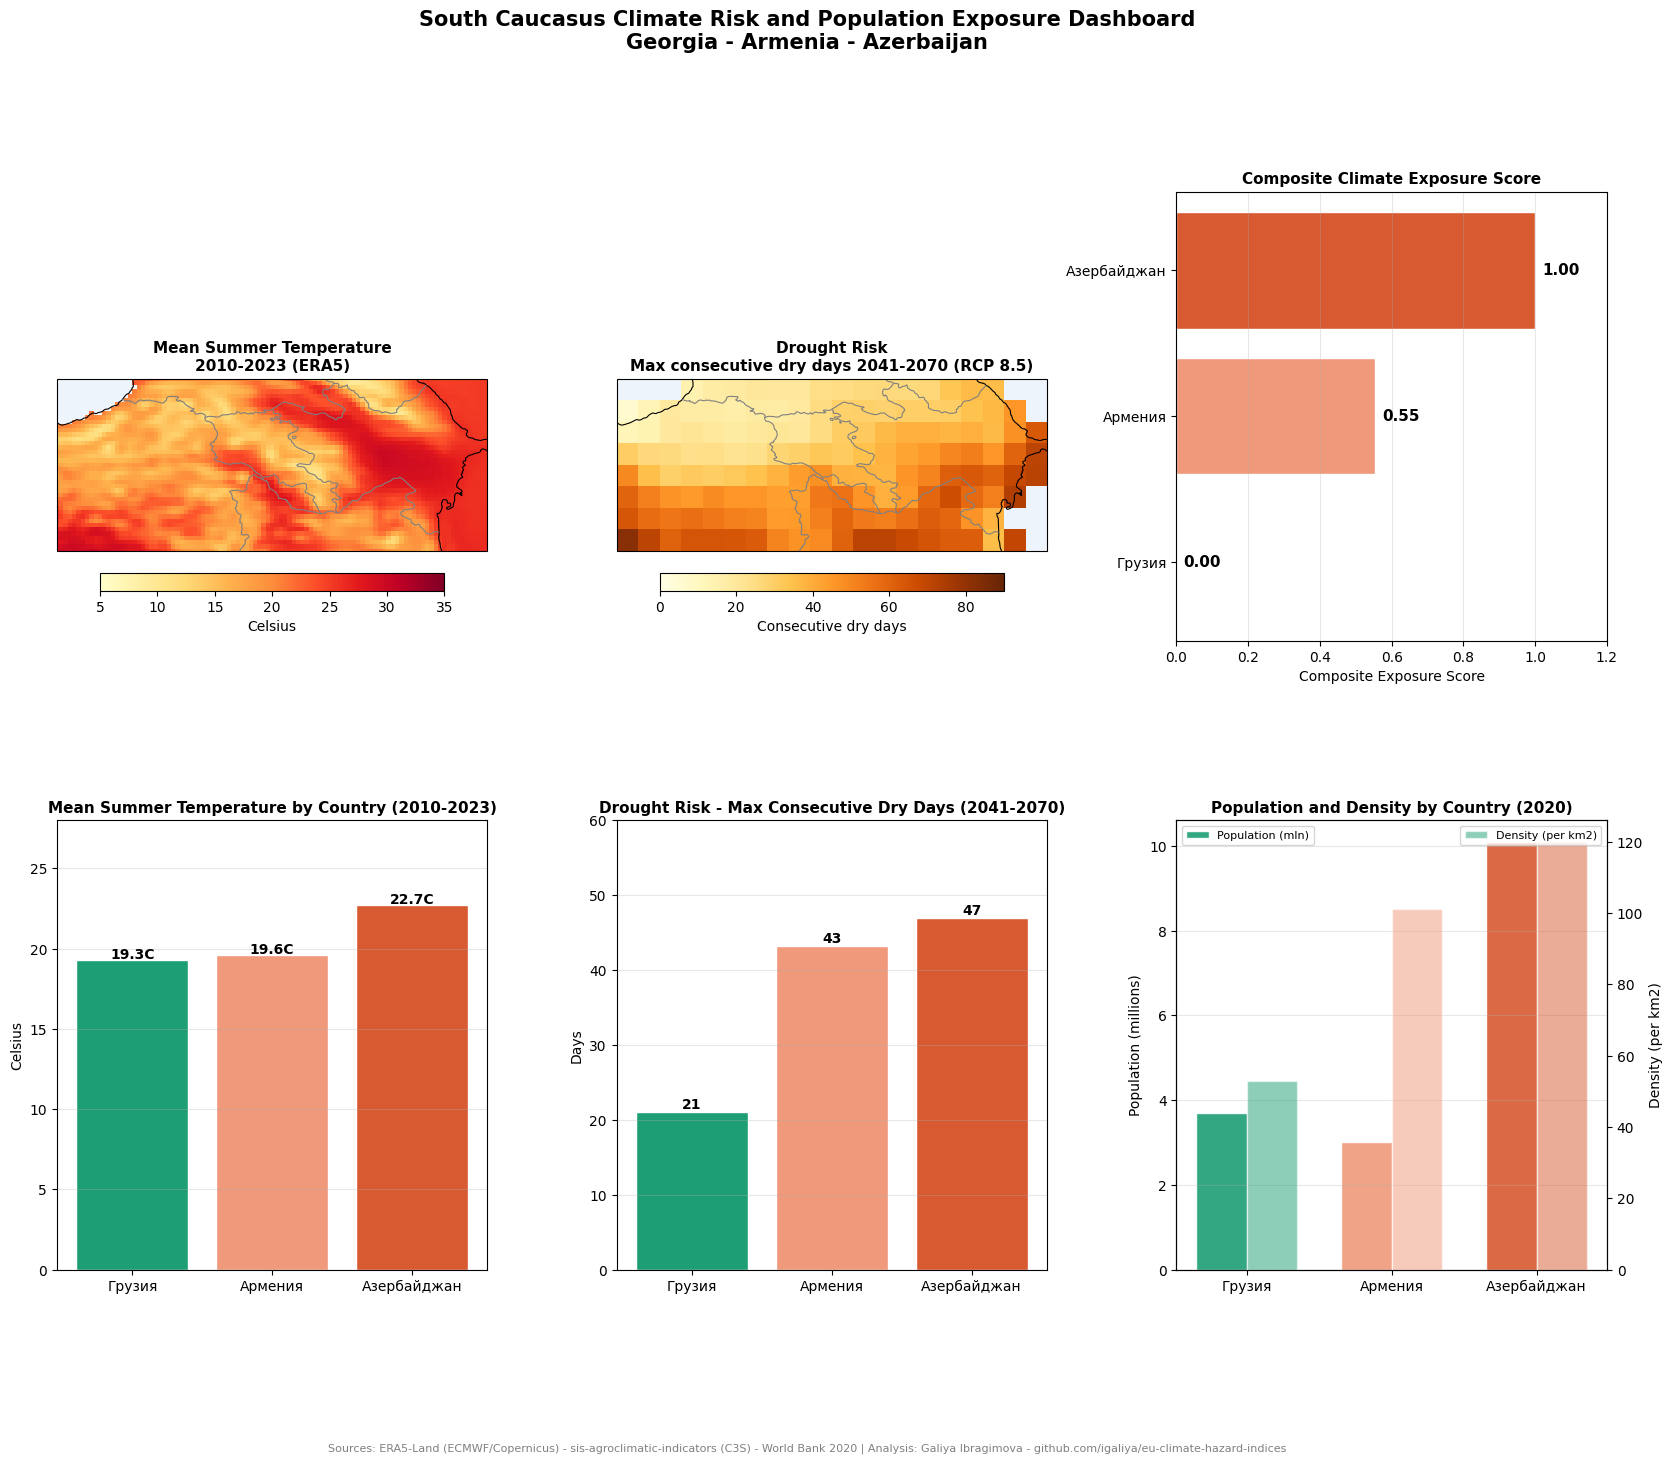

✅ Дашборд сохранён!


In [23]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(20, 14))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.3)

# КАРТА 1: ТЕМПЕРАТУРА
ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
t2m_mean = t2m.mean(dim='valid_time')
im1 = ax1.pcolormesh(temp.longitude, temp.latitude, t2m_mean, transform=ccrs.PlateCarree(), cmap='YlOrRd', vmin=5, vmax=35)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax1.add_feature(cfeature.BORDERS, linewidth=0.8, color='gray')
ax1.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax1.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax1.set_extent([40, 50, 38, 42], crs=ccrs.PlateCarree())
ax1.set_title('Mean Summer Temperature\n2010-2023 (ERA5)', fontsize=11, fontweight='bold')
plt.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.8, label='Celsius')

# КАРТА 2: ЗАСУХА
ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
im2 = ax2.pcolormesh(drought_caucasus.lon, drought_caucasus.lat, drought_caucasus, transform=ccrs.PlateCarree(), cmap='YlOrBr', vmin=0, vmax=90)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax2.add_feature(cfeature.BORDERS, linewidth=0.8, color='gray')
ax2.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax2.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax2.set_extent([40, 50, 38, 42], crs=ccrs.PlateCarree())
ax2.set_title('Drought Risk\nMax consecutive dry days 2041-2070 (RCP 8.5)', fontsize=11, fontweight='bold')
plt.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.8, label='Consecutive dry days')

# ГРАФИК 3: EXPOSURE SCORE
ax3 = fig.add_subplot(gs[0, 2])
countries_list = df['Страна'].tolist()
scores = df['exposure_score'].tolist()
colors = ['#1D9E75', '#F0997B', '#D85A30']
bars = ax3.barh(countries_list, scores, color=colors, edgecolor='white')
ax3.set_xlim(0, 1.2)
ax3.set_xlabel('Composite Exposure Score', fontsize=10)
ax3.set_title('Composite Climate Exposure Score', fontsize=11, fontweight='bold')
for i, (bar, score) in enumerate(zip(bars, scores)):
    ax3.text(score + 0.02, bar.get_y() + bar.get_height()/2, f'{score:.2f}', va='center', fontsize=11, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# ГРАФИК 4: ТЕМПЕРАТУРА ПО СТРАНАМ
ax4 = fig.add_subplot(gs[1, 0])
temps = df['Летняя_температура_C'].tolist()
bars4 = ax4.bar(countries_list, temps, color=colors, edgecolor='white')
ax4.set_ylabel('Celsius', fontsize=10)
ax4.set_title('Mean Summer Temperature by Country (2010-2023)', fontsize=11, fontweight='bold')
for bar, val in zip(bars4, temps):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.1f}C', ha='center', fontsize=10, fontweight='bold')
ax4.set_ylim(0, 28)
ax4.grid(axis='y', alpha=0.3)

# ГРАФИК 5: ЗАСУХА ПО СТРАНАМ
ax5 = fig.add_subplot(gs[1, 1])
cdds = df['Засуха_CDD_дней'].tolist()
bars5 = ax5.bar(countries_list, cdds, color=colors, edgecolor='white')
ax5.set_ylabel('Days', fontsize=10)
ax5.set_title('Drought Risk - Max Consecutive Dry Days (2041-2070)', fontsize=11, fontweight='bold')
for bar, val in zip(bars5, cdds):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.0f}', ha='center', fontsize=10, fontweight='bold')
ax5.set_ylim(0, 60)
ax5.grid(axis='y', alpha=0.3)

# ГРАФИК 6: НАСЕЛЕНИЕ
ax6 = fig.add_subplot(gs[1, 2])
pop = df['Население_млн'].tolist()
density = df['Плотность_чел_км2'].tolist()
x = np.arange(len(countries_list))
width = 0.35
bars6a = ax6.bar(x - width/2, pop, width, label='Population (mln)', color=colors, edgecolor='white', alpha=0.9)
ax6b = ax6.twinx()
bars6b = ax6b.bar(x + width/2, density, width, label='Density (per km2)', color=colors, edgecolor='white', alpha=0.5)
ax6.set_ylabel('Population (millions)', fontsize=10)
ax6b.set_ylabel('Density (per km2)', fontsize=10)
ax6.set_title('Population and Density by Country (2020)', fontsize=11, fontweight='bold')
ax6.set_xticks(x)
ax6.set_xticklabels(countries_list)
ax6.legend(loc='upper left', fontsize=8)
ax6b.legend(loc='upper right', fontsize=8)
ax6.grid(axis='y', alpha=0.3)

# ЗАГОЛОВОК
fig.suptitle('South Caucasus Climate Risk and Population Exposure Dashboard\nGeorgia - Armenia - Azerbaijan', fontsize=15, fontweight='bold', y=1.01)

# ИСТОЧНИКИ
fig.text(0.5, -0.02, 'Sources: ERA5-Land (ECMWF/Copernicus) - sis-agroclimatic-indicators (C3S) - World Bank 2020 | Analysis: Galiya Ibragimova - github.com/igaliya/eu-climate-hazard-indices', ha='center', fontsize=8, color='gray')

plt.savefig('C:/Users/Galiya/south_caucasus_climate_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Дашборд сохранён!")

In [24]:
import urllib.request
import os

os.makedirs("C:/Users/Galiya/climate_risk_data/population", exist_ok=True)

# Прямая ссылка на GHS-POP 2020, разрешение 1km, WGS84
url = "https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/GHSL/GHS_POP_GLOBE_R2023A/GHS_POP_E2020_GLOBE_R2023A_4326_30ss/V1-0/GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0.zip"

print("⏳ Скачиваем данные по населению JRC GHSL 2020...")
print("Файл большой (~400MB) — займёт несколько минут...")

urllib.request.urlretrieve(
    url,
    "C:/Users/Galiya/climate_risk_data/population/GHS_POP_2020.zip"
)
print("✅ Данные по населению скачаны!")

⏳ Скачиваем данные по населению JRC GHSL 2020...
Файл большой (~400MB) — займёт несколько минут...
✅ Данные по населению скачаны!


In [25]:
import cdsapi
c = cdsapi.Client()

print("⏳ Скачиваем данные по осадкам...")
c.retrieve(
    'reanalysis-era5-land-monthly-means',
    {
        'product_type': 'monthly_averaged_reanalysis',
        'variable': 'total_precipitation',
        'year': [str(y) for y in range(2010, 2024)],
        'month': ['01','02','03','04','05','06',
                  '07','08','09','10','11','12'],
        'time': '00:00',
        'area': [42, 40, 38, 50],
        'format': 'netcdf'
    },
    'C:/Users/Galiya/climate_risk_data/caucasus/precipitation_caucasus.zip'
)
print("✅ Данные по осадкам скачаны!")

⏳ Скачиваем данные по осадкам...


2026-09-11 13:09:13,807 INFO Request ID is fe9676cf-22cf-4036-8238-85327a4506fd
2026-09-11 13:09:13,927 INFO status has been updated to accepted
2026-09-11 13:09:30,835 INFO status has been updated to running
2026-09-11 13:10:07,137 INFO status has been updated to successful


a3b94e00f4f31ecde8cee7f50b17109c.zip:   0%|          | 0.00/1.77M [00:00<?, ?B/s]

✅ Данные по осадкам скачаны!


In [26]:
import zipfile
import os

print("⏳ Разархивируем данные по населению...")
with zipfile.ZipFile("C:/Users/Galiya/climate_risk_data/population/GHS_POP_2020.zip", "r") as zip_ref:
    zip_ref.extractall("C:/Users/Galiya/climate_risk_data/population/")

print("📁 Файлы по населению:")
for f in os.listdir("C:/Users/Galiya/climate_risk_data/population/"):
    size_mb = os.path.getsize(os.path.join("C:/Users/Galiya/climate_risk_data/population/", f)) / (1024*1024)
    print(f" — {f} ({size_mb:.1f} MB)")

⏳ Разархивируем данные по населению...
📁 Файлы по населению:
 — GHSL_Data_Package_2023.pdf (14.4 MB)
 — GHS_POP_2020.zip (460.0 MB)
 — GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0.tif (365.2 MB)
 — GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0.tif.ovr (111.2 MB)
 — GHS_POP_GLOBE_R2023A_input_metadata.xlsx (0.1 MB)


In [27]:
import zipfile
import os

# Разархивируем осадки
precip_zip = "C:/Users/Galiya/climate_risk_data/caucasus/precipitation_caucasus.zip"

# Проверяем формат файла
with open(precip_zip, 'rb') as f:
    header = f.read(4)
    print(f"Формат файла: {header}")

if header[:2] == b'PK':
    print("ZIP архив — разархивируем...")
    with zipfile.ZipFile(precip_zip, 'r') as zip_ref:
        zip_ref.extractall("C:/Users/Galiya/climate_risk_data/caucasus/")
    print("📁 Файлы после разархивирования:")
    for f in os.listdir("C:/Users/Galiya/climate_risk_data/caucasus/"):
        size_mb = os.path.getsize(os.path.join("C:/Users/Galiya/climate_risk_data/caucasus/", f)) / (1024*1024)
        print(f" — {f} ({size_mb:.1f} MB)")
else:
    print("Другой формат — открываем напрямую")

Формат файла: b'PK\x03\x04'
ZIP архив — разархивируем...


PermissionError: [Errno 13] Permission denied

In [28]:
import zipfile
import os

# Разархивируем в отдельную папку
os.makedirs("C:/Users/Galiya/climate_risk_data/caucasus/precip", exist_ok=True)

with zipfile.ZipFile("C:/Users/Galiya/climate_risk_data/caucasus/precipitation_caucasus.zip", 'r') as zip_ref:
    zip_ref.extractall("C:/Users/Galiya/climate_risk_data/caucasus/precip/")

print("📁 Файлы по осадкам:")
for f in os.listdir("C:/Users/Galiya/climate_risk_data/caucasus/precip/"):
    size_mb = os.path.getsize(os.path.join("C:/Users/Galiya/climate_risk_data/caucasus/precip/", f)) / (1024*1024)
    print(f" — {f} ({size_mb:.1f} MB)")

📁 Файлы по осадкам:
 — data_stream-moda.nc (1.8 MB)


In [29]:
import xarray as xr
import numpy as np

# Открываем осадки
precip = xr.open_dataset(
    "C:/Users/Galiya/climate_risk_data/caucasus/precip/data_stream-moda.nc",
    engine='netcdf4'
)

print("📊 Структура данных по осадкам:")
print(precip)
print()
print("📅 Переменные:", list(precip.data_vars))

# Конвертируем из м/с в мм/месяц
tp = precip['tp'] * 1000 * 30  # метры -> мм, день -> месяц
print(f"\n🌧️ Осадки (мм/месяц):")
print(f"Минимум: {float(tp.min()):.1f} мм")
print(f"Максимум: {float(tp.max()):.1f} мм")
print(f"Среднее: {float(tp.mean()):.1f} мм")

📊 Структура данных по осадкам:
<xarray.Dataset> Size: 3MB
Dimensions:     (valid_time: 168, latitude: 41, longitude: 101)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 1kB 2010-01-01 ... 2023-12-01
    expver      (valid_time) <U4 3kB ...
  * latitude    (latitude) float64 328B 42.0 41.9 41.8 41.7 ... 38.2 38.1 38.0
  * longitude   (longitude) float64 808B 40.0 40.1 40.2 40.3 ... 49.8 49.9 50.0
    number      int64 8B ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 3MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-11T11:09 GRIB to CDM+CF via cfgrib-0.9.1...

📅 Переменные: ['tp']

🌧️ Осадки (мм/месяц):
Минимум: 0.0 мм
Максимум: 632.5 мм
Среднее: 58.9 мм


In [30]:
# Среднегодовые осадки по странам
# Конвертируем в мм/год
tp_annual = precip['tp'] * 1000 * 365  # метры/день -> мм/год
tp_mean = tp_annual.mean(dim='valid_time')

countries_precip = {
    'Грузия':      {'latitude': slice(42, 41), 'longitude': slice(40, 47)},
    'Армения':     {'latitude': slice(41, 38), 'longitude': slice(43, 47)},
    'Азербайджан': {'latitude': slice(42, 38), 'longitude': slice(45, 50)},
}

print("🌧️ Среднегодовые осадки 2010-2023 (мм/год):")
for country, coords in countries_precip.items():
    subset = tp_mean.sel(
        latitude=coords['latitude'],
        longitude=coords['longitude']
    ).mean()
    print(f" — {country}: {float(subset):.0f} мм/год")

🌧️ Среднегодовые осадки 2010-2023 (мм/год):
 — Грузия: 1047 мм/год
 — Армения: 657 мм/год
 — Азербайджан: 587 мм/год


In [31]:
import pandas as pd
import numpy as np

# Обновлённая таблица с осадками
population_data = {
    'Страна': ['Грузия', 'Армения', 'Азербайджан'],
    'Население_млн': [3.7, 3.0, 10.1],
    'Плотность_чел_км2': [53, 101, 120],
    'Летняя_температура_C': [19.3, 19.6, 22.7],
    'Осадки_мм_год': [1047, 657, 587],
    'Засуха_CDD_дней': [21.0, 43.2, 46.9],
}

df = pd.DataFrame(population_data)

# Нормализуем каждый индикатор
# Для осадков — инвертируем (меньше осадков = выше риск)
df['temp_norm'] = (df['Летняя_температура_C'] - df['Летняя_температура_C'].min()) / \
                  (df['Летняя_температура_C'].max() - df['Летняя_температура_C'].min())

df['precip_norm'] = 1 - ((df['Осадки_мм_год'] - df['Осадки_мм_год'].min()) / \
                    (df['Осадки_мм_год'].max() - df['Осадки_мм_год'].min()))

df['drought_norm'] = (df['Засуха_CDD_дней'] - df['Засуха_CDD_дней'].min()) / \
                     (df['Засуха_CDD_дней'].max() - df['Засуха_CDD_дней'].min())

df['density_norm'] = (df['Плотность_чел_км2'] - df['Плотность_чел_км2'].min()) / \
                     (df['Плотность_чел_км2'].max() - df['Плотность_чел_км2'].min())

# Composite score — среднее четырёх индикаторов
df['exposure_score'] = (df['temp_norm'] + df['precip_norm'] + 
                        df['drought_norm'] + df['density_norm']) / 4

print("📊 Обновлённый Composite Exposure Score:")
print(df[['Страна', 'Летняя_температура_C', 'Осадки_мм_год', 
          'Засуха_CDD_дней', 'Плотность_чел_км2', 'exposure_score']].to_string(index=False))

📊 Обновлённый Composite Exposure Score:
     Страна  Летняя_температура_C  Осадки_мм_год  Засуха_CDD_дней  Плотность_чел_км2  exposure_score
     Грузия                  19.3           1047             21.0                 53        0.000000
    Армения                  19.6            657             43.2                101        0.627406
Азербайджан                  22.7            587             46.9                120        1.000000


In [32]:
import rasterio
import numpy as np

# Открываем GeoTIFF населения JRC
pop_file = "C:/Users/Galiya/climate_risk_data/population/GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0.tif"

with rasterio.open(pop_file) as src:
    print(f"📊 Структура данных населения:")
    print(f"CRS: {src.crs}")
    print(f"Разрешение: {src.res}")
    print(f"Размер: {src.width} x {src.height}")
    print(f"Bounds: {src.bounds}")
    
    # Читаем только регион Южного Кавказа
    # lat 38-42, lon 40-50
    from rasterio.windows import from_bounds
    window = from_bounds(40, 38, 50, 42, src.transform)
    pop_caucasus = src.read(1, window=window)
    
    print(f"\n✅ Регион Южного Кавказа:")
    print(f"Размер: {pop_caucasus.shape}")
    print(f"Макс. население в ячейке: {pop_caucasus.max():.0f}")
    print(f"Общее население: {pop_caucasus[pop_caucasus > 0].sum()/1e6:.1f} млн")

ModuleNotFoundError: No module named 'rasterio'

In [33]:
import xarray as xr
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import from_bounds

# Переменные температуры
temp = xr.open_dataset("C:/Users/Galiya/climate_risk_data/caucasus/data_stream-moda.nc", engine='netcdf4')
t2m = temp['t2m'] - 273.15

# Переменные осадков
precip = xr.open_dataset("C:/Users/Galiya/climate_risk_data/caucasus/precip/data_stream-moda.nc", engine='netcdf4')
tp_annual = precip['tp'] * 1000 * 365
tp_mean = tp_annual.mean(dim='valid_time')

# Drought данные
drought_ds = xr.open_dataset("C:/Users/Galiya/climate_risk_data/drought/CDD_C3S-glob-agric_hadgem2-es_rcp8p5_season_20410101-20701231_v1.0.nc")
drought_caucasus = drought_ds.CDD.sel(
    time=drought_ds.time.dt.month == 7,
    lat=slice(38, 42),
    lon=slice(40, 50)
).mean(dim='time')

# DataFrame
df = pd.DataFrame({
    'Страна': ['Грузия', 'Армения', 'Азербайджан'],
    'Население_млн': [3.7, 3.0, 10.1],
    'Плотность_чел_км2': [53, 101, 120],
    'Летняя_температура_C': [19.3, 19.6, 22.7],
    'Осадки_мм_год': [1047, 657, 587],
    'Засуха_CDD_дней': [21.0, 43.2, 46.9],
})

# Нормализация и exposure score
df['temp_norm'] = (df['Летняя_температура_C'] - df['Летняя_температура_C'].min()) / (df['Летняя_температура_C'].max() - df['Летняя_температура_C'].min())
df['precip_norm'] = 1 - ((df['Осадки_мм_год'] - df['Осадки_мм_год'].min()) / (df['Осадки_мм_год'].max() - df['Осадки_мм_год'].min()))
df['drought_norm'] = (df['Засуха_CDD_дней'] - df['Засуха_CDD_дней'].min()) / (df['Засуха_CDD_дней'].max() - df['Засуха_CDD_дней'].min())
df['density_norm'] = (df['Плотность_чел_км2'] - df['Плотность_чел_км2'].min()) / (df['Плотность_чел_км2'].max() - df['Плотность_чел_км2'].min())
df['exposure_score'] = (df['temp_norm'] + df['precip_norm'] + df['drought_norm'] + df['density_norm']) / 4

print("✅ Все

SyntaxError: unterminated string literal (detected at line 41) (1719843831.py, line 41)

In [34]:
import xarray as xr
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import from_bounds

# Переменные температуры
temp = xr.open_dataset("C:/Users/Galiya/climate_risk_data/caucasus/data_stream-moda.nc", engine='netcdf4')
t2m = temp['t2m'] - 273.15

# Переменные осадков
precip = xr.open_dataset("C:/Users/Galiya/climate_risk_data/caucasus/precip/data_stream-moda.nc", engine='netcdf4')
tp_annual = precip['tp'] * 1000 * 365
tp_mean = tp_annual.mean(dim='valid_time')

# Drought данные
drought_ds = xr.open_dataset("C:/Users/Galiya/climate_risk_data/drought/CDD_C3S-glob-agric_hadgem2-es_rcp8p5_season_20410101-20701231_v1.0.nc")
drought_caucasus = drought_ds.CDD.sel(
    time=drought_ds.time.dt.month == 7,
    lat=slice(38, 42),
    lon=slice(40, 50)
).mean(dim='time')

# DataFrame
df = pd.DataFrame({
    'Страна': ['Грузия', 'Армения', 'Азербайджан'],
    'Население_млн': [3.7, 3.0, 10.1],
    'Плотность_чел_км2': [53, 101, 120],
    'Летняя_температура_C': [19.3, 19.6, 22.7],
    'Осадки_мм_год': [1047, 657, 587],
    'Засуха_CDD_дней': [21.0, 43.2, 46.9],
})

# Нормализация и exposure score
df['temp_norm'] = (df['Летняя_температура_C'] - df['Летняя_температура_C'].min()) / (df['Летняя_температура_C'].max() - df['Летняя_температура_C'].min())
df['precip_norm'] = 1 - ((df['Осадки_мм_год'] - df['Осадки_мм_год'].min()) / (df['Осадки_мм_год'].max() - df['Осадки_мм_год'].min()))
df['drought_norm'] = (df['Засуха_CDD_дней'] - df['Засуха_CDD_дней'].min()) / (df['Засуха_CDD_дней'].max() - df['Засуха_CDD_дней'].min())
df['density_norm'] = (df['Плотность_чел_км2'] - df['Плотность_чел_км2'].min()) / (df['Плотность_чел_км2'].max() - df['Плотность_чел_км2'].min())
df['exposure_score'] = (df['temp_norm'] + df['precip_norm'] + df['drought_norm'] + df['density_norm']) / 4

print("Все данные загружены!")
print(df[['Страна', 'Летняя_температура_C', 'Осадки_мм_год', 'Засуха_CDD_дней', 'exposure_score']])

Все данные загружены!
        Страна  Летняя_температура_C  Осадки_мм_год  Засуха_CDD_дней  \
0       Грузия                  19.3           1047             21.0   
1      Армения                  19.6            657             43.2   
2  Азербайджан                  22.7            587             46.9   

   exposure_score  
0        0.000000  
1        0.627406  
2        1.000000  


In [35]:
import rasterio
from rasterio.windows import from_bounds

# Открываем GeoTIFF населения JRC
pop_file = "C:/Users/Galiya/climate_risk_data/population/GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0.tif"

with rasterio.open(pop_file) as src:
    print("Структура данных населения:")
    print(f"CRS: {src.crs}")
    print(f"Разрешение: {src.res}")
    print(f"Размер: {src.width} x {src.height}")
    
    # Читаем только регион Южного Кавказа lat 38-42, lon 40-50
    window = from_bounds(40, 38, 50, 42, src.transform)
    pop_caucasus = src.read(1, window=window)
    
    # Убираем отрицательные значения (NoData)
    pop_caucasus[pop_caucasus < 0] = 0
    
    print(f"\nРегион Южного Кавказа:")
    print(f"Размер: {pop_caucasus.shape}")
    print(f"Макс. население в ячейке: {pop_caucasus.max():.0f}")
    print(f"Общее население: {pop_caucasus.sum()/1e6:.1f} млн")

Структура данных населения:
CRS: EPSG:4326
Разрешение: (0.00833333330032682, 0.008333333299795073)
Размер: 43202 x 21384

Регион Южного Кавказа:
Размер: (480, 1200)
Макс. население в ячейке: 133582
Общее население: 26.4 млн


C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


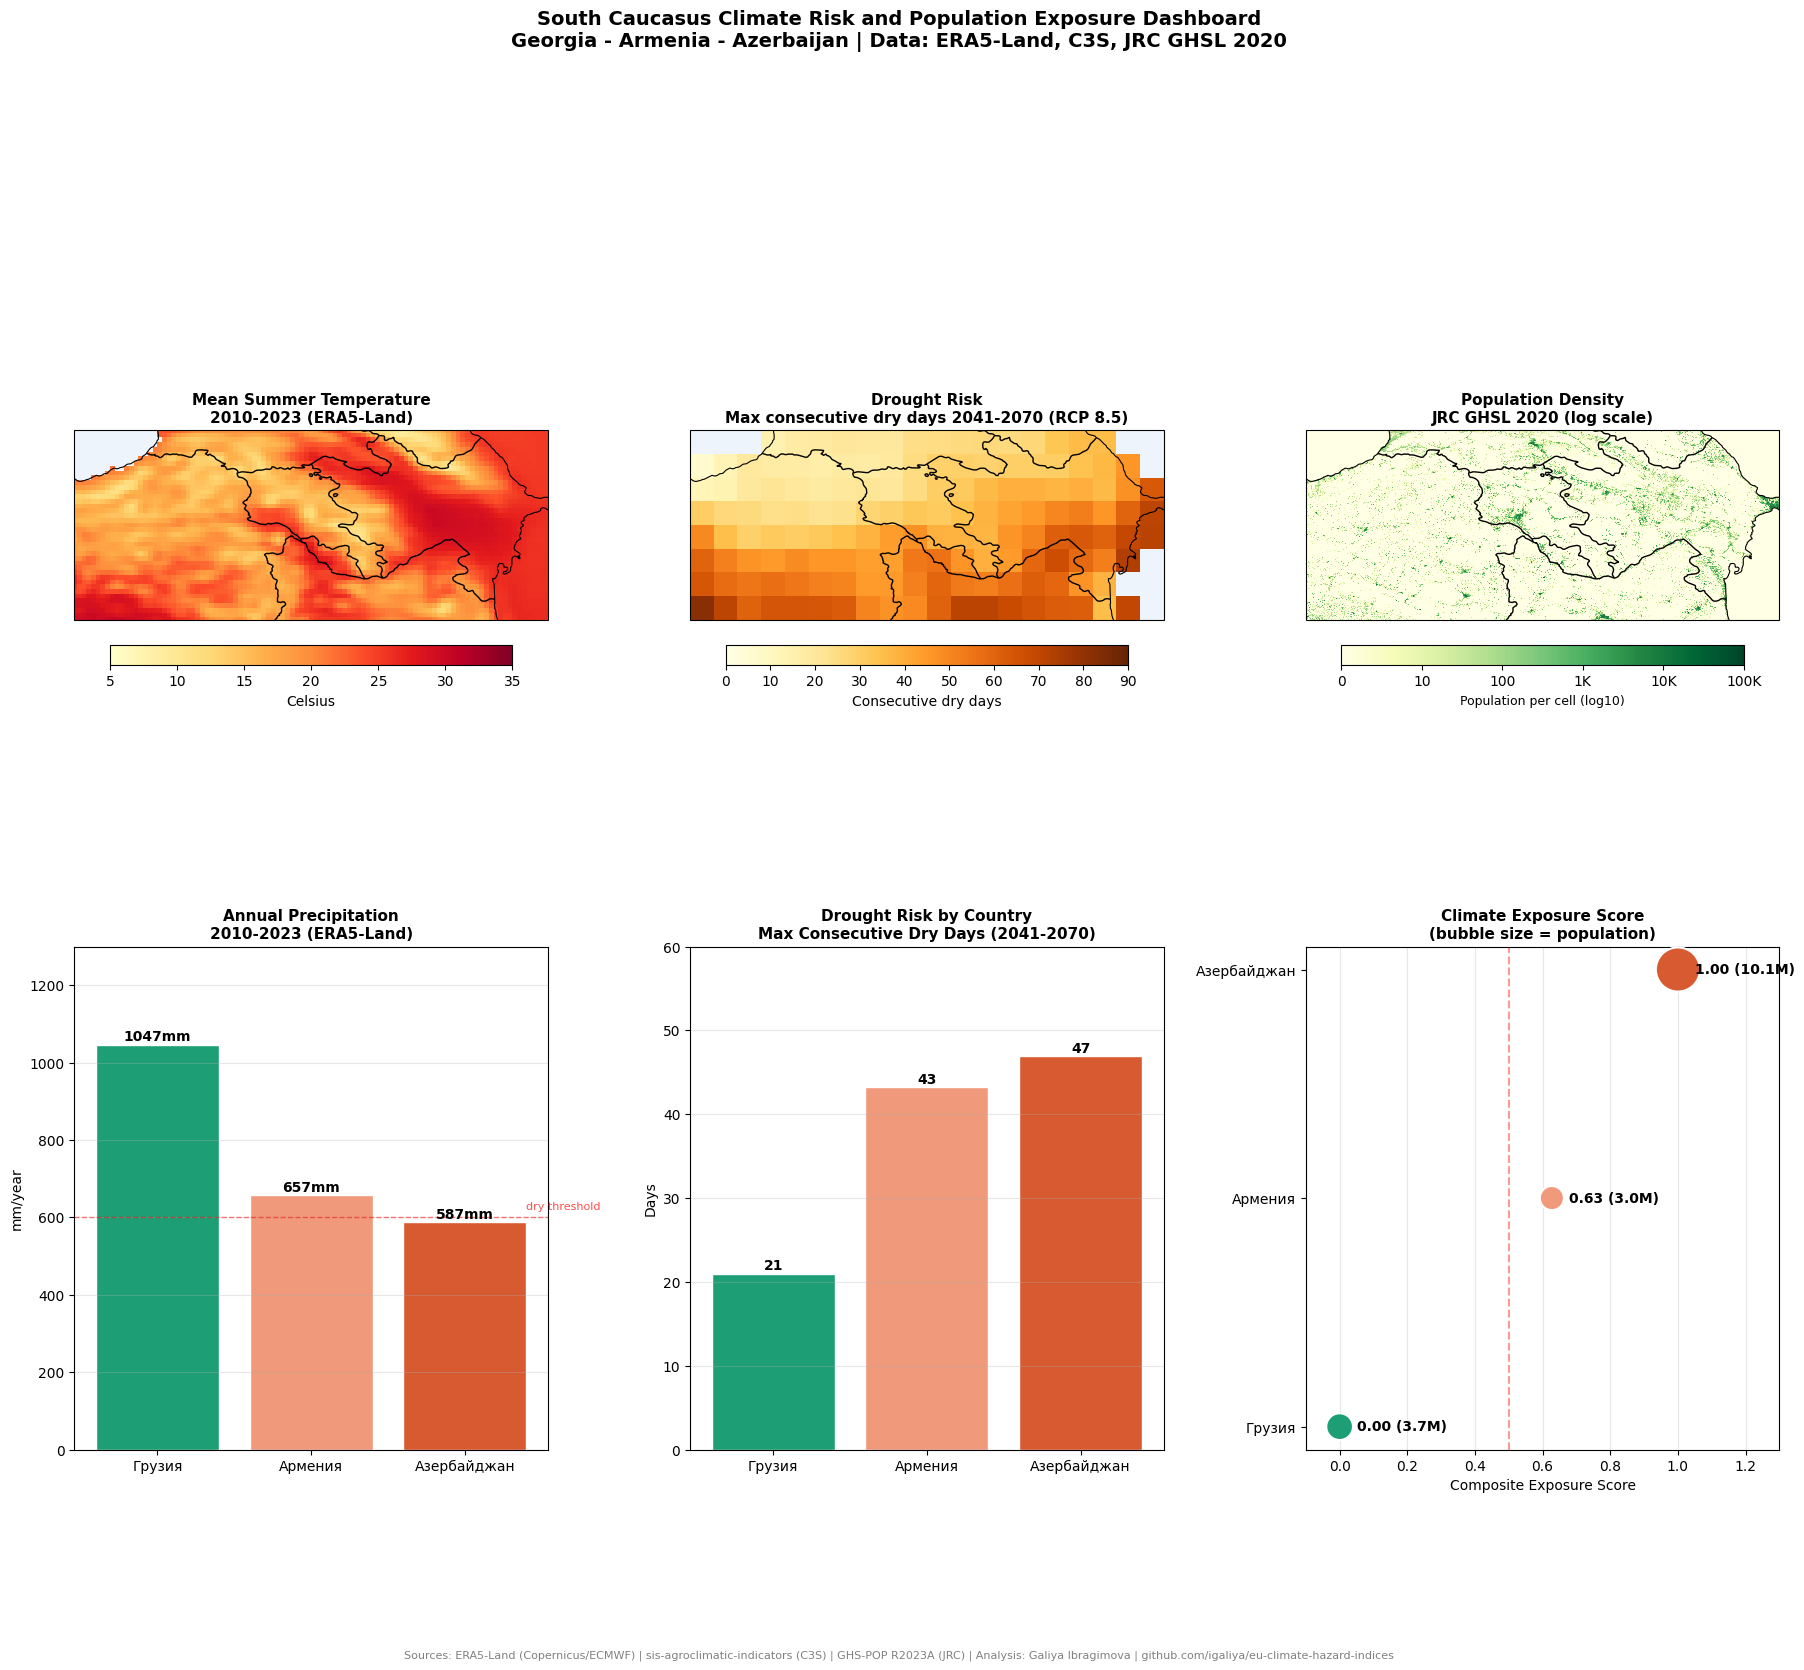

Dashboard saved!


In [36]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rasterio
from rasterio.windows import from_bounds

fig = plt.figure(figsize=(22, 16))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.3)

extent = [40, 50, 38, 42]

# КАРТА 1: ТЕМПЕРАТУРА
ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
t2m_mean = t2m.mean(dim='valid_time')
im1 = ax1.pcolormesh(temp.longitude, temp.latitude, t2m_mean, transform=ccrs.PlateCarree(), cmap='YlOrRd', vmin=5, vmax=35)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax1.add_feature(cfeature.BORDERS, linewidth=1.0, color='black')
ax1.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax1.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax1.set_extent(extent, crs=ccrs.PlateCarree())
ax1.set_title('Mean Summer Temperature\n2010-2023 (ERA5-Land)', fontsize=11, fontweight='bold')
plt.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.85, label='Celsius')

# КАРТА 2: ЗАСУХА
ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
im2 = ax2.pcolormesh(drought_caucasus.lon, drought_caucasus.lat, drought_caucasus, transform=ccrs.PlateCarree(), cmap='YlOrBr', vmin=0, vmax=90)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax2.add_feature(cfeature.BORDERS, linewidth=1.0, color='black')
ax2.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax2.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax2.set_extent(extent, crs=ccrs.PlateCarree())
ax2.set_title('Drought Risk\nMax consecutive dry days 2041-2070 (RCP 8.5)', fontsize=11, fontweight='bold')
plt.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.85, label='Consecutive dry days')

# КАРТА 3: НАСЕЛЕНИЕ JRC GHSL
ax3 = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())
pop_file = "C:/Users/Galiya/climate_risk_data/population/GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0.tif"
with rasterio.open(pop_file) as src:
    window = from_bounds(40, 38, 50, 42, src.transform)
    pop_data = src.read(1, window=window).astype(float)
    pop_data[pop_data < 0] = np.nan
    pop_transform = src.window_transform(window)

lons = np.linspace(40, 50, pop_data.shape[1])
lats = np.linspace(42, 38, pop_data.shape[0])
lon_grid, lat_grid = np.meshgrid(lons, lats)

pop_log = np.log10(pop_data + 1)
im3 = ax3.pcolormesh(lon_grid, lat_grid, pop_log, transform=ccrs.PlateCarree(), cmap='YlGn', vmin=0, vmax=5)
ax3.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax3.add_feature(cfeature.BORDERS, linewidth=1.0, color='black')
ax3.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax3.set_extent(extent, crs=ccrs.PlateCarree())
ax3.set_title('Population Density\nJRC GHSL 2020 (log scale)', fontsize=11, fontweight='bold')
cbar3 = plt.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.85)
cbar3.set_label('Population per cell (log10)', fontsize=9)
cbar3.set_ticks([0, 1, 2, 3, 4, 5])
cbar3.set_ticklabels(['0', '10', '100', '1K', '10K', '100K'])

# ГРАФИК 4: ОСАДКИ
ax4 = fig.add_subplot(gs[1, 0])
colors = ['#1D9E75', '#F0997B', '#D85A30']
countries_list = df['Страна'].tolist()
precip_vals = df['Осадки_мм_год'].tolist()
bars4 = ax4.bar(countries_list, precip_vals, color=colors, edgecolor='white')
ax4.set_ylabel('mm/year', fontsize=10)
ax4.set_title('Annual Precipitation\n2010-2023 (ERA5-Land)', fontsize=11, fontweight='bold')
for bar, val in zip(bars4, precip_vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f'{val:.0f}mm', ha='center', fontsize=10, fontweight='bold')
ax4.set_ylim(0, 1300)
ax4.grid(axis='y', alpha=0.3)
ax4.axhline(y=600, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax4.text(2.4, 620, 'dry threshold', fontsize=8, color='red', alpha=0.7)

# ГРАФИК 5: ЗАСУХА ПО СТРАНАМ
ax5 = fig.add_subplot(gs[1, 1])
cdds = df['Засуха_CDD_дней'].tolist()
bars5 = ax5.bar(countries_list, cdds, color=colors, edgecolor='white')
ax5.set_ylabel('Days', fontsize=10)
ax5.set_title('Drought Risk by Country\nMax Consecutive Dry Days (2041-2070)', fontsize=11, fontweight='bold')
for bar, val in zip(bars5, cdds):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.0f}', ha='center', fontsize=10, fontweight='bold')
ax5.set_ylim(0, 60)
ax5.grid(axis='y', alpha=0.3)

# ГРАФИК 6: EXPOSURE SCORE
ax6 = fig.add_subplot(gs[1, 2])
scores = df['exposure_score'].tolist()
pop_millions = df['Население_млн'].tolist()
scatter = ax6.scatter(scores, countries_list, s=[p*100 for p in pop_millions], color=colors, edgecolor='white', linewidth=1.5, zorder=3)
ax6.set_xlim(-0.1, 1.3)
ax6.set_xlabel('Composite Exposure Score', fontsize=10)
ax6.set_title('Climate Exposure Score\n(bubble size = population)', fontsize=11, fontweight='bold')
for i, (score, country, pop) in enumerate(zip(scores, countries_list, pop_millions)):
    ax6.text(score + 0.05, i, f'{score:.2f} ({pop}M)', va='center', fontsize=10, fontweight='bold')
ax6.grid(axis='x', alpha=0.3)
ax6.axvline(x=0.5, color='red', linestyle='--', alpha=0.4)

fig.suptitle('South Caucasus Climate Risk and Population Exposure Dashboard\nGeorgia - Armenia - Azerbaijan | Data: ERA5-Land, C3S, JRC GHSL 2020', fontsize=14, fontweight='bold', y=1.01)
fig.text(0.5, -0.02, 'Sources: ERA5-Land (Copernicus/ECMWF) | sis-agroclimatic-indicators (C3S) | GHS-POP R2023A (JRC) | Analysis: Galiya Ibragimova | github.com/igaliya/eu-climate-hazard-indices', ha='center', fontsize=8, color='gray')

plt.savefig('C:/Users/Galiya/south_caucasus_climate_dashboard_v2.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Dashboard saved!")

In [37]:
import cartopy.feature as cfeature

# Добавим более толстые границы и названия стран
ax1.add_feature(cfeature.BORDERS, linewidth=1.5, color='black', zorder=5)

# Добавим названия стран
ax1.text(43.5, 41.5, 'GEORGIA', transform=ccrs.PlateCarree(), 
         fontsize=9, fontweight='bold', color='black', ha='center')
ax1.text(44.5, 40.0, 'ARMENIA', transform=ccrs.PlateCarree(),
         fontsize=9, fontweight='bold', color='black', ha='center')
ax1.text(47.5, 40.5, 'AZERBAIJAN', transform=ccrs.PlateCarree(),
         fontsize=9, fontweight='bold', color='black', ha='center')

C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Text(47.5, 40.5, 'AZERBAIJAN')

C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


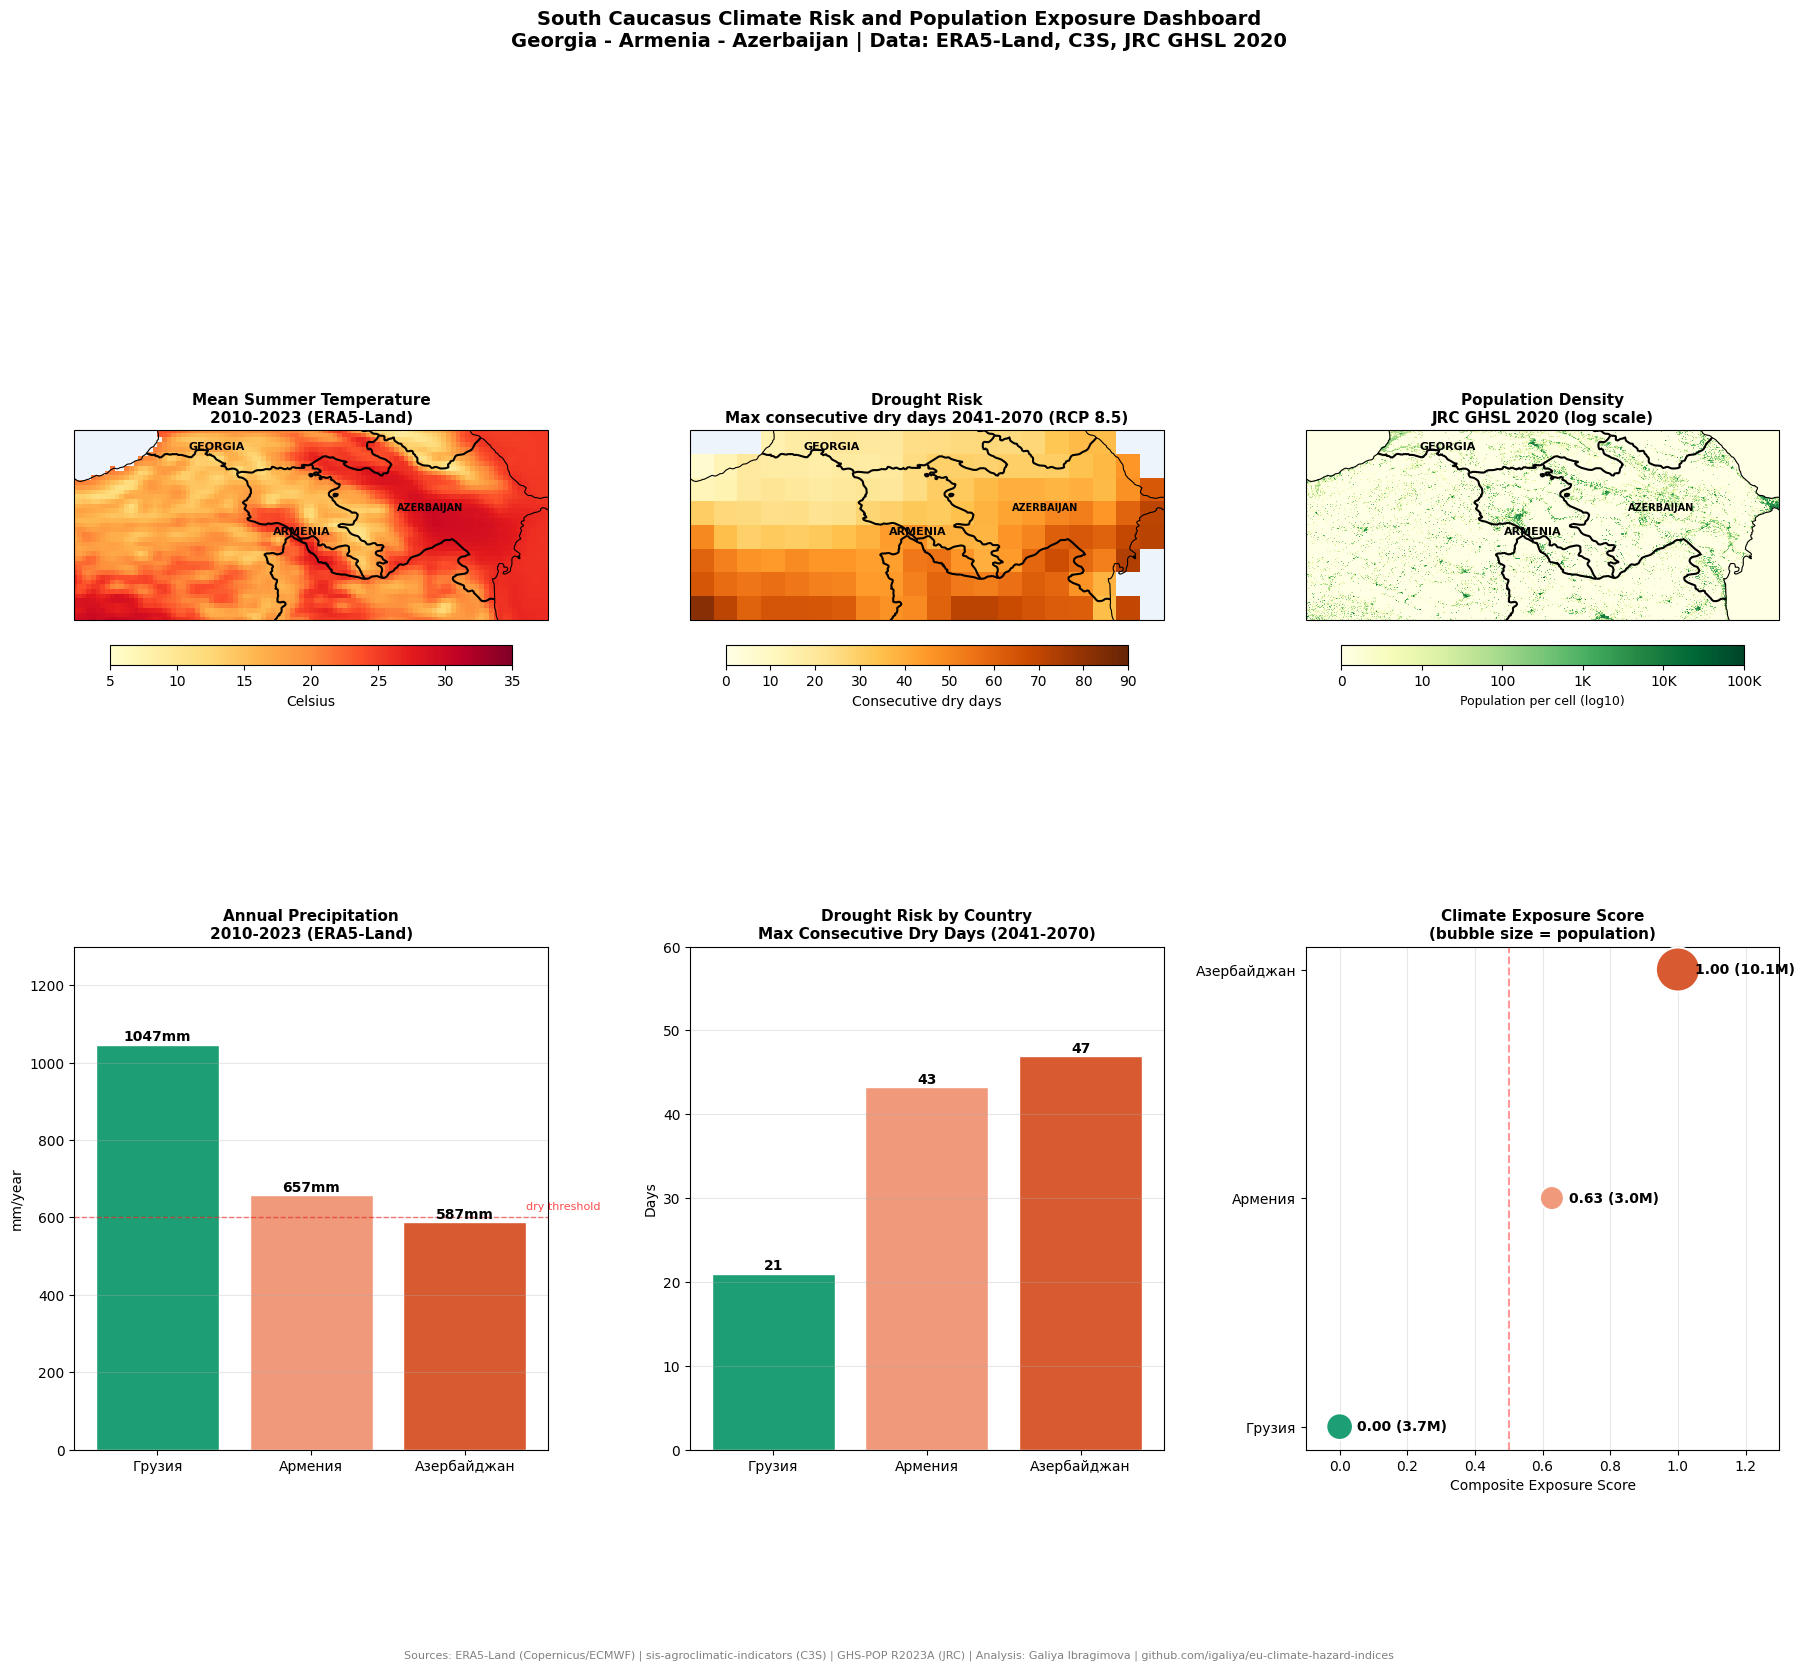

Dashboard saved!


In [39]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rasterio
from rasterio.windows import from_bounds

fig = plt.figure(figsize=(22, 16))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.3)
extent = [40, 50, 38, 42]

# КАРТА 1: ТЕМПЕРАТУРА
ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
t2m_mean = t2m.mean(dim='valid_time')
im1 = ax1.pcolormesh(temp.longitude, temp.latitude, t2m_mean, transform=ccrs.PlateCarree(), cmap='YlOrRd', vmin=5, vmax=35)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax1.add_feature(cfeature.BORDERS, linewidth=1.5, color='black', zorder=5)
ax1.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax1.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax1.set_extent(extent, crs=ccrs.PlateCarree())
ax1.set_title('Mean Summer Temperature\n2010-2023 (ERA5-Land)', fontsize=11, fontweight='bold')
ax1.text(43.0, 41.6, 'GEORGIA', transform=ccrs.PlateCarree(), fontsize=8, fontweight='bold', color='black', ha='center', zorder=6)
ax1.text(44.8, 39.8, 'ARMENIA', transform=ccrs.PlateCarree(), fontsize=8, fontweight='bold', color='black', ha='center', zorder=6)
ax1.text(47.5, 40.3, 'AZERBAIJAN', transform=ccrs.PlateCarree(), fontsize=7, fontweight='bold', color='black', ha='center', zorder=6)
plt.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.85, label='Celsius')

# КАРТА 2: ЗАСУХА
ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
im2 = ax2.pcolormesh(drought_caucasus.lon, drought_caucasus.lat, drought_caucasus, transform=ccrs.PlateCarree(), cmap='YlOrBr', vmin=0, vmax=90)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax2.add_feature(cfeature.BORDERS, linewidth=1.5, color='black', zorder=5)
ax2.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax2.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax2.set_extent(extent, crs=ccrs.PlateCarree())
ax2.set_title('Drought Risk\nMax consecutive dry days 2041-2070 (RCP 8.5)', fontsize=11, fontweight='bold')
ax2.text(43.0, 41.6, 'GEORGIA', transform=ccrs.PlateCarree(), fontsize=8, fontweight='bold', color='black', ha='center', zorder=6)
ax2.text(44.8, 39.8, 'ARMENIA', transform=ccrs.PlateCarree(), fontsize=8, fontweight='bold', color='black', ha='center', zorder=6)
ax2.text(47.5, 40.3, 'AZERBAIJAN', transform=ccrs.PlateCarree(), fontsize=7, fontweight='bold', color='black', ha='center', zorder=6)
plt.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.85, label='Consecutive dry days')

# КАРТА 3: НАСЕЛЕНИЕ JRC
ax3 = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())
pop_file = "C:/Users/Galiya/climate_risk_data/population/GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0.tif"
with rasterio.open(pop_file) as src:
    window = from_bounds(40, 38, 50, 42, src.transform)
    pop_data = src.read(1, window=window).astype(float)
    pop_data[pop_data < 0] = np.nan

lons = np.linspace(40, 50, pop_data.shape[1])
lats = np.linspace(42, 38, pop_data.shape[0])
lon_grid, lat_grid = np.meshgrid(lons, lats)
pop_log = np.log10(pop_data + 1)
im3 = ax3.pcolormesh(lon_grid, lat_grid, pop_log, transform=ccrs.PlateCarree(), cmap='YlGn', vmin=0, vmax=5)
ax3.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax3.add_feature(cfeature.BORDERS, linewidth=1.5, color='black', zorder=5)
ax3.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax3.set_extent(extent, crs=ccrs.PlateCarree())
ax3.set_title('Population Density\nJRC GHSL 2020 (log scale)', fontsize=11, fontweight='bold')
ax3.text(43.0, 41.6, 'GEORGIA', transform=ccrs.PlateCarree(), fontsize=8, fontweight='bold', color='black', ha='center', zorder=6)
ax3.text(44.8, 39.8, 'ARMENIA', transform=ccrs.PlateCarree(), fontsize=8, fontweight='bold', color='black', ha='center', zorder=6)
ax3.text(47.5, 40.3, 'AZERBAIJAN', transform=ccrs.PlateCarree(), fontsize=7, fontweight='bold', color='black', ha='center', zorder=6)
cbar3 = plt.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.85)
cbar3.set_label('Population per cell (log10)', fontsize=9)
cbar3.set_ticks([0, 1, 2, 3, 4, 5])
cbar3.set_ticklabels(['0', '10', '100', '1K', '10K', '100K'])

# ГРАФИК 4: ОСАДКИ
ax4 = fig.add_subplot(gs[1, 0])
colors = ['#1D9E75', '#F0997B', '#D85A30']
countries_list = df['Страна'].tolist()
precip_vals = df['Осадки_мм_год'].tolist()
bars4 = ax4.bar(countries_list, precip_vals, color=colors, edgecolor='white')
ax4.set_ylabel('mm/year', fontsize=10)
ax4.set_title('Annual Precipitation\n2010-2023 (ERA5-Land)', fontsize=11, fontweight='bold')
for bar, val in zip(bars4, precip_vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f'{val:.0f}mm', ha='center', fontsize=10, fontweight='bold')
ax4.set_ylim(0, 1300)
ax4.grid(axis='y', alpha=0.3)
ax4.axhline(y=600, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax4.text(2.4, 620, 'dry threshold', fontsize=8, color='red', alpha=0.7)

# ГРАФИК 5: ЗАСУХА
ax5 = fig.add_subplot(gs[1, 1])
cdds = df['Засуха_CDD_дней'].tolist()
bars5 = ax5.bar(countries_list, cdds, color=colors, edgecolor='white')
ax5.set_ylabel('Days', fontsize=10)
ax5.set_title('Drought Risk by Country\nMax Consecutive Dry Days (2041-2070)', fontsize=11, fontweight='bold')
for bar, val in zip(bars5, cdds):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.0f}', ha='center', fontsize=10, fontweight='bold')
ax5.set_ylim(0, 60)
ax5.grid(axis='y', alpha=0.3)

# ГРАФИК 6: BUBBLE CHART
ax6 = fig.add_subplot(gs[1, 2])
scores = df['exposure_score'].tolist()
pop_millions = df['Население_млн'].tolist()
scatter = ax6.scatter(scores, countries_list, s=[p*100 for p in pop_millions], color=colors, edgecolor='white', linewidth=1.5, zorder=3)
ax6.set_xlim(-0.1, 1.3)
ax6.set_xlabel('Composite Exposure Score', fontsize=10)
ax6.set_title('Climate Exposure Score\n(bubble size = population)', fontsize=11, fontweight='bold')
for i, (score, country, pop) in enumerate(zip(scores, countries_list, pop_millions)):
    ax6.text(score + 0.05, i, f'{score:.2f} ({pop}M)', va='center', fontsize=10, fontweight='bold')
ax6.grid(axis='x', alpha=0.3)
ax6.axvline(x=0.5, color='red', linestyle='--', alpha=0.4)

# ЗАГОЛОВОК И ИСТОЧНИКИ
fig.suptitle('South Caucasus Climate Risk and Population Exposure Dashboard\nGeorgia - Armenia - Azerbaijan | Data: ERA5-Land, C3S, JRC GHSL 2020', fontsize=14, fontweight='bold', y=1.01)
fig.text(0.5, -0.02, 'Sources: ERA5-Land (Copernicus/ECMWF) | sis-agroclimatic-indicators (C3S) | GHS-POP R2023A (JRC) | Analysis: Galiya Ibragimova | github.com/igaliya/eu-climate-hazard-indices', ha='center', fontsize=8, color='gray')

plt.savefig('C:/Users/Galiya/south_caucasus_climate_dashboard_v3.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Dashboard saved!")

C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


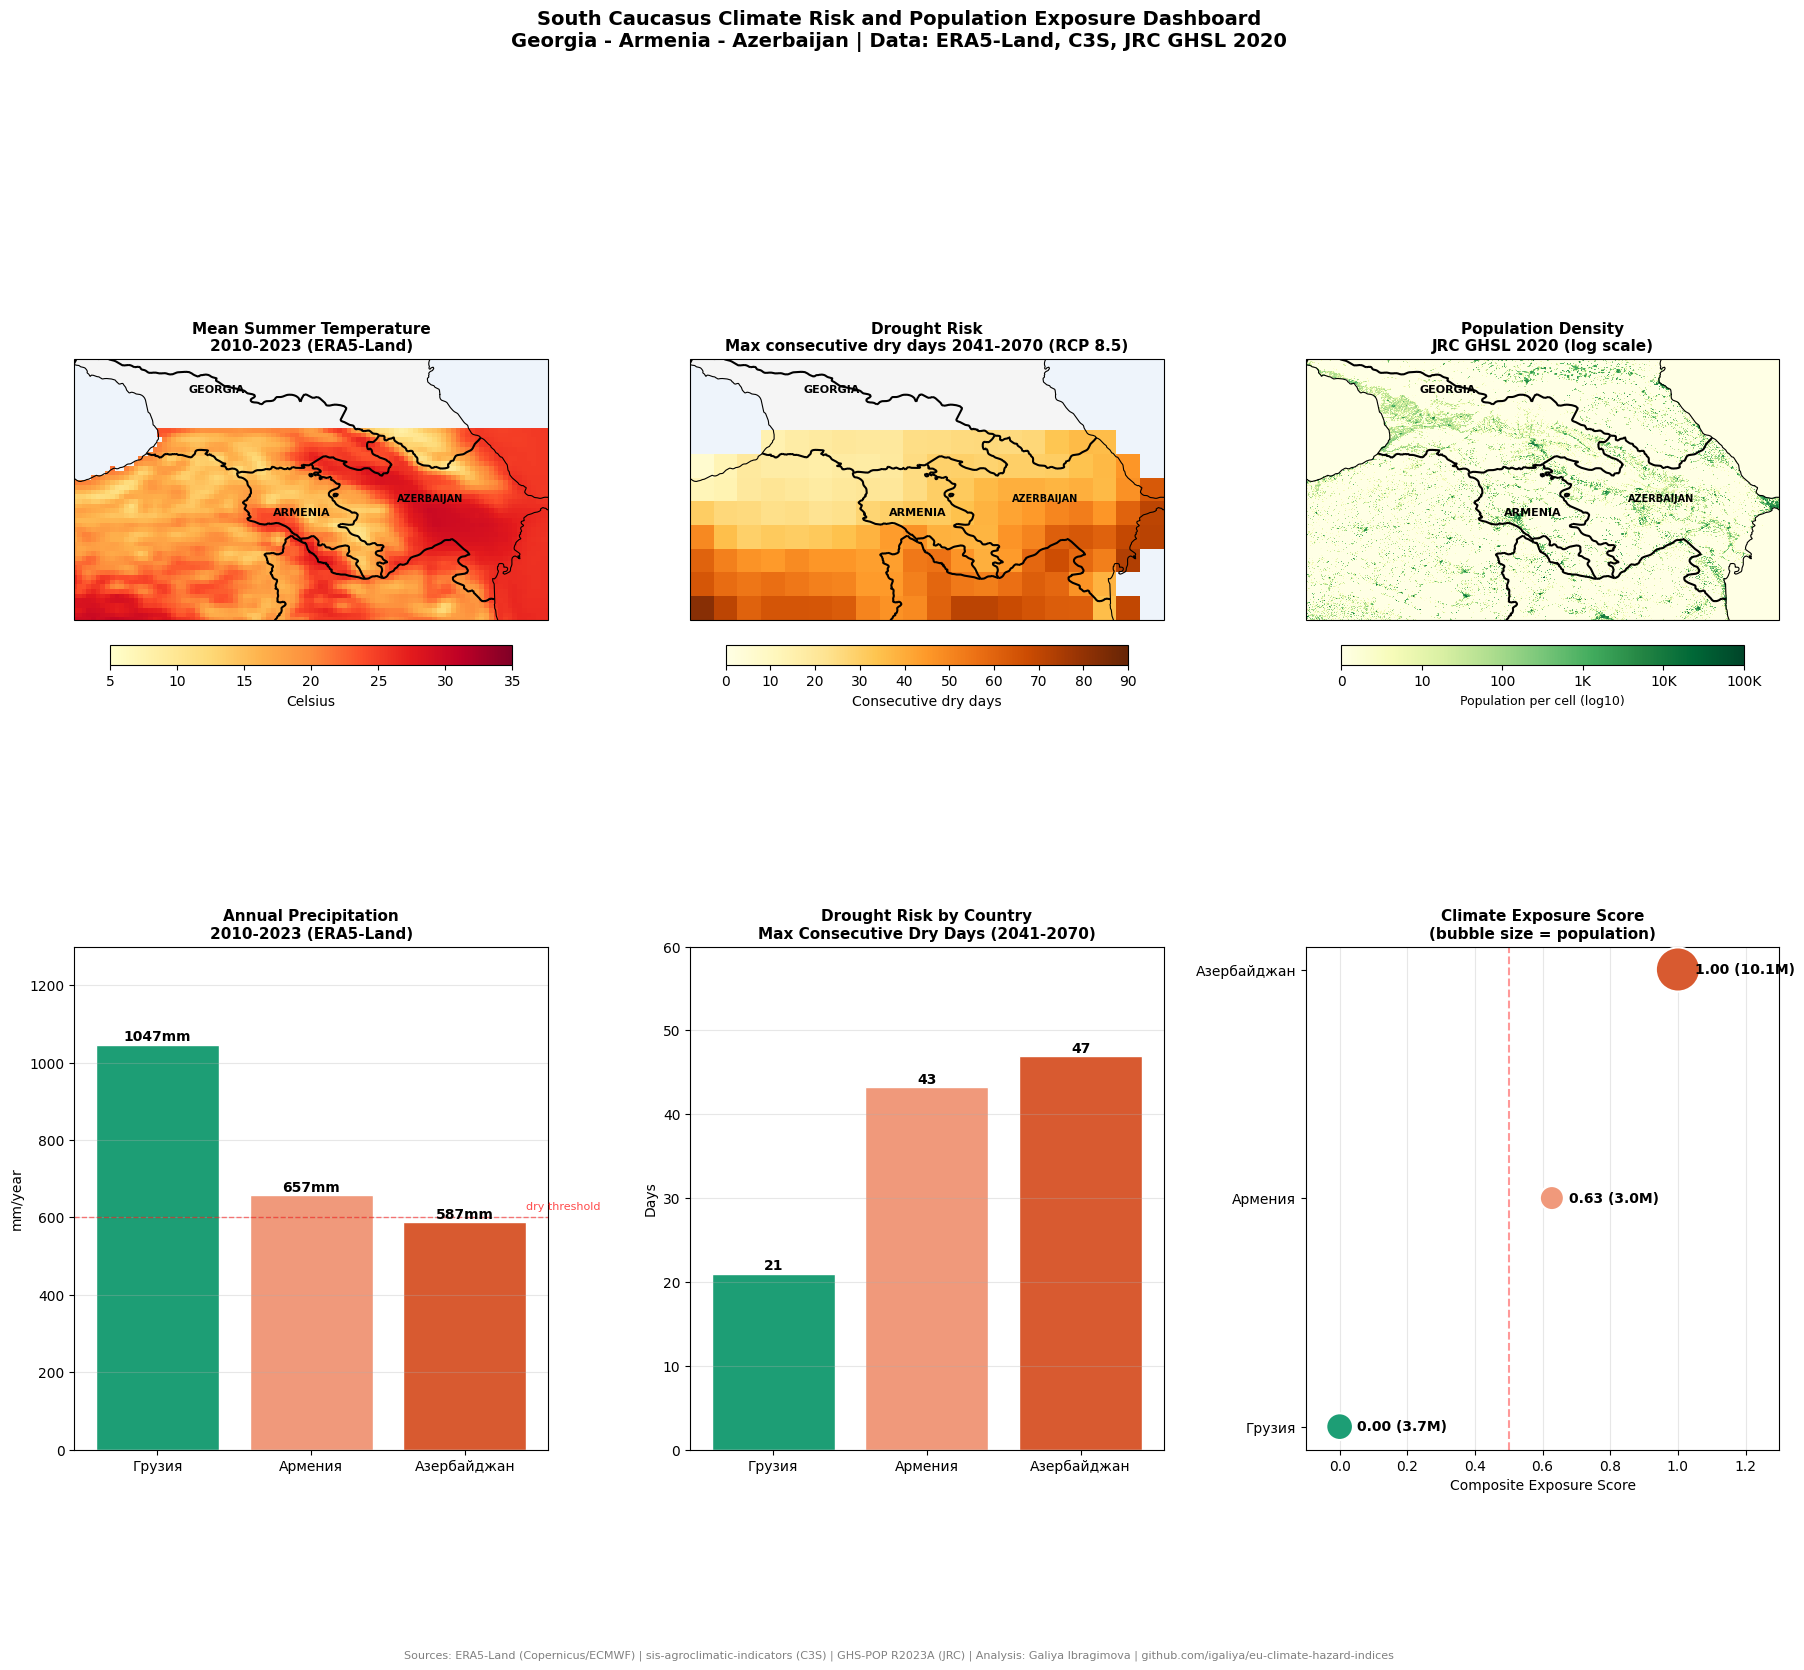

Dashboard saved!


In [40]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rasterio
from rasterio.windows import from_bounds

fig = plt.figure(figsize=(22, 16))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.3)
extent = [40, 50, 38, 43.5]

# КАРТА 1: ТЕМПЕРАТУРА
ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
t2m_mean = t2m.mean(dim='valid_time')
im1 = ax1.pcolormesh(temp.longitude, temp.latitude, t2m_mean, transform=ccrs.PlateCarree(), cmap='YlOrRd', vmin=5, vmax=35)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax1.add_feature(cfeature.BORDERS, linewidth=1.5, color='black', zorder=5)
ax1.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax1.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax1.set_extent(extent, crs=ccrs.PlateCarree())
ax1.set_title('Mean Summer Temperature\n2010-2023 (ERA5-Land)', fontsize=11, fontweight='bold')
ax1.text(43.0, 42.8, 'GEORGIA', transform=ccrs.PlateCarree(), fontsize=8, fontweight='bold', color='black', ha='center', zorder=6)
ax1.text(44.8, 40.2, 'ARMENIA', transform=ccrs.PlateCarree(), fontsize=8, fontweight='bold', color='black', ha='center', zorder=6)
ax1.text(47.5, 40.5, 'AZERBAIJAN', transform=ccrs.PlateCarree(), fontsize=7, fontweight='bold', color='black', ha='center', zorder=6)
plt.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.85, label='Celsius')

# КАРТА 2: ЗАСУХА
ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
im2 = ax2.pcolormesh(drought_caucasus.lon, drought_caucasus.lat, drought_caucasus, transform=ccrs.PlateCarree(), cmap='YlOrBr', vmin=0, vmax=90)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax2.add_feature(cfeature.BORDERS, linewidth=1.5, color='black', zorder=5)
ax2.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax2.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax2.set_extent(extent, crs=ccrs.PlateCarree())
ax2.set_title('Drought Risk\nMax consecutive dry days 2041-2070 (RCP 8.5)', fontsize=11, fontweight='bold')
ax2.text(43.0, 42.8, 'GEORGIA', transform=ccrs.PlateCarree(), fontsize=8, fontweight='bold', color='black', ha='center', zorder=6)
ax2.text(44.8, 40.2, 'ARMENIA', transform=ccrs.PlateCarree(), fontsize=8, fontweight='bold', color='black', ha='center', zorder=6)
ax2.text(47.5, 40.5, 'AZERBAIJAN', transform=ccrs.PlateCarree(), fontsize=7, fontweight='bold', color='black', ha='center', zorder=6)
plt.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.85, label='Consecutive dry days')

# КАРТА 3: НАСЕЛЕНИЕ
ax3 = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())
pop_file = "C:/Users/Galiya/climate_risk_data/population/GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0.tif"
with rasterio.open(pop_file) as src:
    window = from_bounds(40, 38, 50, 43.5, src.transform)
    pop_data = src.read(1, window=window).astype(float)
    pop_data[pop_data < 0] = np.nan
lons = np.linspace(40, 50, pop_data.shape[1])
lats = np.linspace(43.5, 38, pop_data.shape[0])
lon_grid, lat_grid = np.meshgrid(lons, lats)
pop_log = np.log10(pop_data + 1)
im3 = ax3.pcolormesh(lon_grid, lat_grid, pop_log, transform=ccrs.PlateCarree(), cmap='YlGn', vmin=0, vmax=5)
ax3.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax3.add_feature(cfeature.BORDERS, linewidth=1.5, color='black', zorder=5)
ax3.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax3.set_extent(extent, crs=ccrs.PlateCarree())
ax3.set_title('Population Density\nJRC GHSL 2020 (log scale)', fontsize=11, fontweight='bold')
ax3.text(43.0, 42.8, 'GEORGIA', transform=ccrs.PlateCarree(), fontsize=8, fontweight='bold', color='black', ha='center', zorder=6)
ax3.text(44.8, 40.2, 'ARMENIA', transform=ccrs.PlateCarree(), fontsize=8, fontweight='bold', color='black', ha='center', zorder=6)
ax3.text(47.5, 40.5, 'AZERBAIJAN', transform=ccrs.PlateCarree(), fontsize=7, fontweight='bold', color='black', ha='center', zorder=6)
cbar3 = plt.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.85)
cbar3.set_label('Population per cell (log10)', fontsize=9)
cbar3.set_ticks([0, 1, 2, 3, 4, 5])
cbar3.set_ticklabels(['0', '10', '100', '1K', '10K', '100K'])

# ГРАФИК 4: ОСАДКИ
ax4 = fig.add_subplot(gs[1, 0])
colors = ['#1D9E75', '#F0997B', '#D85A30']
countries_list = df['Страна'].tolist()
precip_vals = df['Осадки_мм_год'].tolist()
bars4 = ax4.bar(countries_list, precip_vals, color=colors, edgecolor='white')
ax4.set_ylabel('mm/year', fontsize=10)
ax4.set_title('Annual Precipitation\n2010-2023 (ERA5-Land)', fontsize=11, fontweight='bold')
for bar, val in zip(bars4, precip_vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f'{val:.0f}mm', ha='center', fontsize=10, fontweight='bold')
ax4.set_ylim(0, 1300)
ax4.grid(axis='y', alpha=0.3)
ax4.axhline(y=600, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax4.text(2.4, 620, 'dry threshold', fontsize=8, color='red', alpha=0.7)

# ГРАФИК 5: ЗАСУХА
ax5 = fig.add_subplot(gs[1, 1])
cdds = df['Засуха_CDD_дней'].tolist()
bars5 = ax5.bar(countries_list, cdds, color=colors, edgecolor='white')
ax5.set_ylabel('Days', fontsize=10)
ax5.set_title('Drought Risk by Country\nMax Consecutive Dry Days (2041-2070)', fontsize=11, fontweight='bold')
for bar, val in zip(bars5, cdds):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.0f}', ha='center', fontsize=10, fontweight='bold')
ax5.set_ylim(0, 60)
ax5.grid(axis='y', alpha=0.3)

# ГРАФИК 6: BUBBLE CHART
ax6 = fig.add_subplot(gs[1, 2])
scores = df['exposure_score'].tolist()
pop_millions = df['Население_млн'].tolist()
ax6.scatter(scores, countries_list, s=[p*100 for p in pop_millions], color=colors, edgecolor='white', linewidth=1.5, zorder=3)
ax6.set_xlim(-0.1, 1.3)
ax6.set_xlabel('Composite Exposure Score', fontsize=10)
ax6.set_title('Climate Exposure Score\n(bubble size = population)', fontsize=11, fontweight='bold')
for i, (score, country, pop) in enumerate(zip(scores, countries_list, pop_millions)):
    ax6.text(score + 0.05, i, f'{score:.2f} ({pop}M)', va='center', fontsize=10, fontweight='bold')
ax6.grid(axis='x', alpha=0.3)
ax6.axvline(x=0.5, color='red', linestyle='--', alpha=0.4)

fig.suptitle('South Caucasus Climate Risk and Population Exposure Dashboard\nGeorgia - Armenia - Azerbaijan | Data: ERA5-Land, C3S, JRC GHSL 2020', fontsize=14, fontweight='bold', y=1.01)
fig.text(0.5, -0.02, 'Sources: ERA5-Land (Copernicus/ECMWF) | sis-agroclimatic-indicators (C3S) | GHS-POP R2023A (JRC) | Analysis: Galiya Ibragimova | github.com/igaliya/eu-climate-hazard-indices', ha='center', fontsize=8, color='gray')

plt.savefig('C:/Users/Galiya/south_caucasus_climate_dashboard_v4.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Dashboard saved!")

In [41]:
# Пересчитываем данные по странам с правильными границами
countries_correct = {
    'Грузия':      {'lat_t': slice(43.5, 41.0), 'lon_t': slice(40, 47),
                    'lat_d': slice(41.0, 43.5),  'lon_d': slice(40, 47)},
    'Армения':     {'lat_t': slice(41.0, 38.5), 'lon_t': slice(43, 47),
                    'lat_d': slice(38.5, 41.0),  'lon_d': slice(43, 47)},
    'Азербайджан': {'lat_t': slice(41.8, 38.3), 'lon_t': slice(45, 50),
                    'lat_d': slice(38.3, 41.8),  'lon_d': slice(45, 50)},
}

print("Пересчитываем температуру и засуху...")
print()

# Температура
print("Летняя температура 2010-2023 (°C):")
for country, coords in countries_correct.items():
    subset = t2m.sel(
        latitude=coords['lat_t'],
        longitude=coords['lon_t']
    ).mean()
    print(f" — {country}: {float(subset):.1f}°C")

print()

# Засуха
print("Засуха CDD 2041-2070 (дней):")
for country, coords in countries_correct.items():
    subset = drought_caucasus.sel(
        lat=coords['lat_d'],
        lon=coords['lon_d']
    ).mean()
    print(f" — {country}: {float(subset):.1f} дней")

Пересчитываем температуру и засуху...

Летняя температура 2010-2023 (°C):
 — Грузия: 19.3°C
 — Армения: 19.4°C
 — Азербайджан: 23.0°C

Засуха CDD 2041-2070 (дней):
 — Грузия: 21.0 дней
 — Армения: 39.8 дней
 — Азербайджан: 44.7 дней


In [42]:
import cdsapi
c = cdsapi.Client()

print("Скачиваем расширенные данные температуры для Грузии...")
c.retrieve(
    'reanalysis-era5-land-monthly-means',
    {
        'product_type': 'monthly_averaged_reanalysis',
        'variable': '2m_temperature',
        'year': [str(y) for y in range(2010, 2024)],
        'month': ['06', '07', '08'],
        'time': '00:00',
        'area': [43.5, 40, 38, 50],
        'format': 'netcdf'
    },
    'C:/Users/Galiya/climate_risk_data/caucasus/temperature_caucasus_v2.zip'
)
print("Готово!")

Скачиваем расширенные данные температуры для Грузии...


2026-09-11 13:43:17,023 INFO Request ID is 1efb10c2-ea8e-47d3-9580-558b526fa1e7
2026-09-11 13:43:17,114 INFO status has been updated to accepted
2026-09-11 13:43:50,026 INFO status has been updated to running
2026-09-11 13:44:07,420 INFO status has been updated to successful


c7435d698ad05579577d6abf457d26f2.zip:   0%|          | 0.00/406k [00:00<?, ?B/s]

Готово!


In [43]:
import zipfile
import os

# Разархивируем
os.makedirs("C:/Users/Galiya/climate_risk_data/caucasus/temp_v2", exist_ok=True)
with zipfile.ZipFile("C:/Users/Galiya/climate_risk_data/caucasus/temperature_caucasus_v2.zip", 'r') as zip_ref:
    zip_ref.extractall("C:/Users/Galiya/climate_risk_data/caucasus/temp_v2/")

print("Файлы:")
for f in os.listdir("C:/Users/Galiya/climate_risk_data/caucasus/temp_v2/"):
    print(f" — {f}")

# Открываем новые данные
temp2 = xr.open_dataset(
    "C:/Users/Galiya/climate_risk_data/caucasus/temp_v2/data_stream-moda.nc",
    engine='netcdf4'
)
t2m2 = temp2['t2m'] - 273.15

print(f"\nПокрытие latitude: {float(temp2.latitude.min()):.1f} — {float(temp2.latitude.max()):.1f}")
print(f"Покрытие longitude: {float(temp2.longitude.min()):.1f} — {float(temp2.longitude.max()):.1f}")

# Пересчитываем по странам
print("\nОбновлённая летняя температура 2010-2023 (C):")
countries_temp = {
    'Грузия':      {'latitude': slice(43.5, 41.0), 'longitude': slice(40, 47)},
    'Армения':     {'latitude': slice(41.0, 38.5), 'longitude': slice(43, 47)},
    'Азербайджан': {'latitude': slice(41.8, 38.3), 'longitude': slice(45, 50)},
}
for country, coords in countries_temp.items():
    subset = t2m2.sel(
        latitude=coords['latitude'],
        longitude=coords['longitude']
    ).mean()
    print(f" — {country}: {float(subset):.1f}C")

Файлы:
 — data_stream-moda.nc

Покрытие latitude: 38.0 — 43.5
Покрытие longitude: 40.0 — 50.0

Обновлённая летняя температура 2010-2023 (C):
 — Грузия: 18.0C
 — Армения: 19.4C
 — Азербайджан: 23.0C


In [44]:
import pandas as pd
import numpy as np

# Обновлённые данные
df = pd.DataFrame({
    'Страна': ['Грузия', 'Армения', 'Азербайджан'],
    'Население_млн': [3.7, 3.0, 10.1],
    'Плотность_чел_км2': [53, 101, 120],
    'Летняя_температура_C': [18.0, 19.4, 23.0],
    'Осадки_мм_год': [1047, 657, 587],
    'Засуха_CDD_дней': [21.0, 39.8, 44.7],
})

# Нормализация
df['temp_norm'] = (df['Летняя_температура_C'] - df['Летняя_температура_C'].min()) / (df['Летняя_температура_C'].max() - df['Летняя_температура_C'].min())
df['precip_norm'] = 1 - ((df['Осадки_мм_год'] - df['Осадки_мм_год'].min()) / (df['Осадки_мм_год'].max() - df['Осадки_мм_год'].min()))
df['drought_norm'] = (df['Засуха_CDD_дней'] - df['Засуха_CDD_дней'].min()) / (df['Засуха_CDD_дней'].max() - df['Засуха_CDD_дней'].min())
df['density_norm'] = (df['Плотность_чел_км2'] - df['Плотность_чел_км2'].min()) / (df['Плотность_чел_км2'].max() - df['Плотность_чел_км2'].min())
df['exposure_score'] = (df['temp_norm'] + df['precip_norm'] + df['drought_norm'] + df['density_norm']) / 4

print("Обновлённый Composite Exposure Score:")
print(df[['Страна', 'Летняя_температура_C', 'Осадки_мм_год', 'Засуха_CDD_дней', 'exposure_score']].to_string(index=False))

Обновлённый Composite Exposure Score:
     Страна  Летняя_температура_C  Осадки_мм_год  Засуха_CDD_дней  exposure_score
     Грузия                  18.0           1047             21.0        0.000000
    Армения                  19.4            657             39.8        0.659373
Азербайджан                  23.0            587             44.7        1.000000


C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


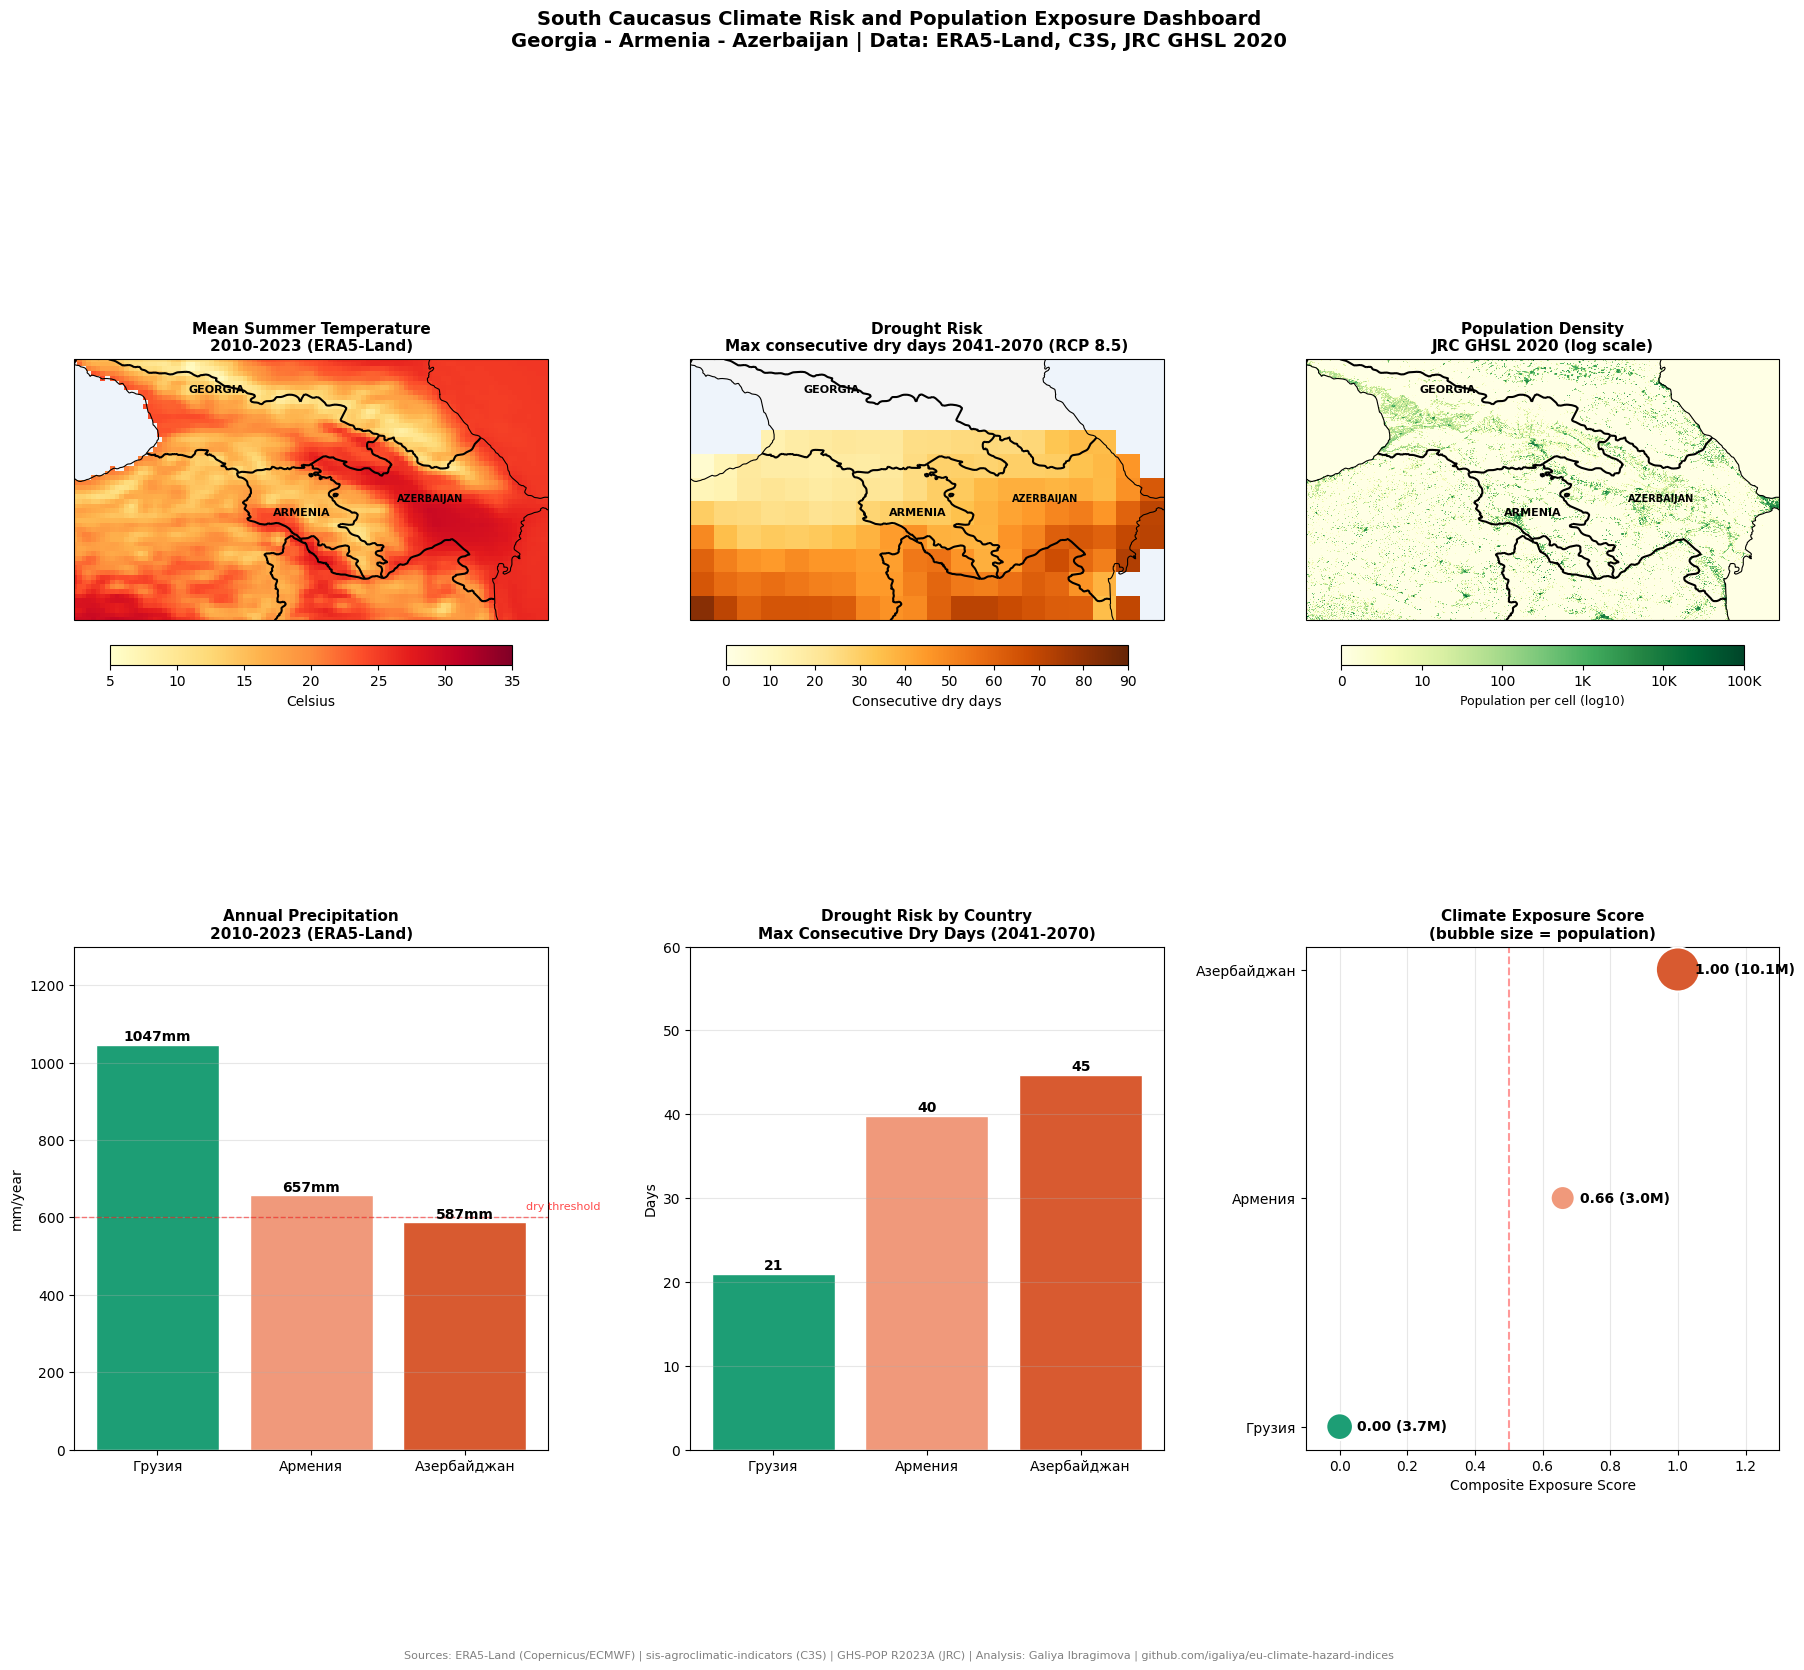

Final dashboard saved!


In [45]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rasterio
from rasterio.windows import from_bounds

fig = plt.figure(figsize=(22, 16))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.3)
extent = [40, 50, 38, 43.5]

# КАРТА 1: ТЕМПЕРАТУРА (обновлённая)
ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
t2m_mean = t2m2.mean(dim='valid_time')
im1 = ax1.pcolormesh(temp2.longitude, temp2.latitude, t2m_mean, transform=ccrs.PlateCarree(), cmap='YlOrRd', vmin=5, vmax=35)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax1.add_feature(cfeature.BORDERS, linewidth=1.5, color='black', zorder=5)
ax1.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax1.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax1.set_extent(extent, crs=ccrs.PlateCarree())
ax1.set_title('Mean Summer Temperature\n2010-2023 (ERA5-Land)', fontsize=11, fontweight='bold')
ax1.text(43.0, 42.8, 'GEORGIA', transform=ccrs.PlateCarree(), fontsize=8, fontweight='bold', color='black', ha='center', zorder=6)
ax1.text(44.8, 40.2, 'ARMENIA', transform=ccrs.PlateCarree(), fontsize=8, fontweight='bold', color='black', ha='center', zorder=6)
ax1.text(47.5, 40.5, 'AZERBAIJAN', transform=ccrs.PlateCarree(), fontsize=7, fontweight='bold', color='black', ha='center', zorder=6)
plt.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.85, label='Celsius')

# КАРТА 2: ЗАСУХА
ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
im2 = ax2.pcolormesh(drought_caucasus.lon, drought_caucasus.lat, drought_caucasus, transform=ccrs.PlateCarree(), cmap='YlOrBr', vmin=0, vmax=90)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax2.add_feature(cfeature.BORDERS, linewidth=1.5, color='black', zorder=5)
ax2.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax2.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax2.set_extent(extent, crs=ccrs.PlateCarree())
ax2.set_title('Drought Risk\nMax consecutive dry days 2041-2070 (RCP 8.5)', fontsize=11, fontweight='bold')
ax2.text(43.0, 42.8, 'GEORGIA', transform=ccrs.PlateCarree(), fontsize=8, fontweight='bold', color='black', ha='center', zorder=6)
ax2.text(44.8, 40.2, 'ARMENIA', transform=ccrs.PlateCarree(), fontsize=8, fontweight='bold', color='black', ha='center', zorder=6)
ax2.text(47.5, 40.5, 'AZERBAIJAN', transform=ccrs.PlateCarree(), fontsize=7, fontweight='bold', color='black', ha='center', zorder=6)
plt.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.85, label='Consecutive dry days')

# КАРТА 3: НАСЕЛЕНИЕ
ax3 = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())
pop_file = "C:/Users/Galiya/climate_risk_data/population/GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0.tif"
with rasterio.open(pop_file) as src:
    window = from_bounds(40, 38, 50, 43.5, src.transform)
    pop_data = src.read(1, window=window).astype(float)
    pop_data[pop_data < 0] = np.nan
lons = np.linspace(40, 50, pop_data.shape[1])
lats = np.linspace(43.5, 38, pop_data.shape[0])
lon_grid, lat_grid = np.meshgrid(lons, lats)
pop_log = np.log10(pop_data + 1)
im3 = ax3.pcolormesh(lon_grid, lat_grid, pop_log, transform=ccrs.PlateCarree(), cmap='YlGn', vmin=0, vmax=5)
ax3.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax3.add_feature(cfeature.BORDERS, linewidth=1.5, color='black', zorder=5)
ax3.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax3.set_extent(extent, crs=ccrs.PlateCarree())
ax3.set_title('Population Density\nJRC GHSL 2020 (log scale)', fontsize=11, fontweight='bold')
ax3.text(43.0, 42.8, 'GEORGIA', transform=ccrs.PlateCarree(), fontsize=8, fontweight='bold', color='black', ha='center', zorder=6)
ax3.text(44.8, 40.2, 'ARMENIA', transform=ccrs.PlateCarree(), fontsize=8, fontweight='bold', color='black', ha='center', zorder=6)
ax3.text(47.5, 40.5, 'AZERBAIJAN', transform=ccrs.PlateCarree(), fontsize=7, fontweight='bold', color='black', ha='center', zorder=6)
cbar3 = plt.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.85)
cbar3.set_label('Population per cell (log10)', fontsize=9)
cbar3.set_ticks([0, 1, 2, 3, 4, 5])
cbar3.set_ticklabels(['0', '10', '100', '1K', '10K', '100K'])

# ГРАФИК 4: ОСАДКИ
ax4 = fig.add_subplot(gs[1, 0])
colors = ['#1D9E75', '#F0997B', '#D85A30']
countries_list = df['Страна'].tolist()
precip_vals = df['Осадки_мм_год'].tolist()
bars4 = ax4.bar(countries_list, precip_vals, color=colors, edgecolor='white')
ax4.set_ylabel('mm/year', fontsize=10)
ax4.set_title('Annual Precipitation\n2010-2023 (ERA5-Land)', fontsize=11, fontweight='bold')
for bar, val in zip(bars4, precip_vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f'{val:.0f}mm', ha='center', fontsize=10, fontweight='bold')
ax4.set_ylim(0, 1300)
ax4.grid(axis='y', alpha=0.3)
ax4.axhline(y=600, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax4.text(2.4, 620, 'dry threshold', fontsize=8, color='red', alpha=0.7)

# ГРАФИК 5: ЗАСУХА
ax5 = fig.add_subplot(gs[1, 1])
cdds = df['Засуха_CDD_дней'].tolist()
bars5 = ax5.bar(countries_list, cdds, color=colors, edgecolor='white')
ax5.set_ylabel('Days', fontsize=10)
ax5.set_title('Drought Risk by Country\nMax Consecutive Dry Days (2041-2070)', fontsize=11, fontweight='bold')
for bar, val in zip(bars5, cdds):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.0f}', ha='center', fontsize=10, fontweight='bold')
ax5.set_ylim(0, 60)
ax5.grid(axis='y', alpha=0.3)

# ГРАФИК 6: BUBBLE CHART
ax6 = fig.add_subplot(gs[1, 2])
scores = df['exposure_score'].tolist()
pop_millions = df['Население_млн'].tolist()
ax6.scatter(scores, countries_list, s=[p*100 for p in pop_millions], color=colors, edgecolor='white', linewidth=1.5, zorder=3)
ax6.set_xlim(-0.1, 1.3)
ax6.set_xlabel('Composite Exposure Score', fontsize=10)
ax6.set_title('Climate Exposure Score\n(bubble size = population)', fontsize=11, fontweight='bold')
for i, (score, country, pop) in enumerate(zip(scores, countries_list, pop_millions)):
    ax6.text(score + 0.05, i, f'{score:.2f} ({pop}M)', va='center', fontsize=10, fontweight='bold')
ax6.grid(axis='x', alpha=0.3)
ax6.axvline(x=0.5, color='red', linestyle='--', alpha=0.4)

fig.suptitle('South Caucasus Climate Risk and Population Exposure Dashboard\nGeorgia - Armenia - Azerbaijan | Data: ERA5-Land, C3S, JRC GHSL 2020', fontsize=14, fontweight='bold', y=1.01)
fig.text(0.5, -0.02, 'Sources: ERA5-Land (Copernicus/ECMWF) | sis-agroclimatic-indicators (C3S) | GHS-POP R2023A (JRC) | Analysis: Galiya Ibragimova | github.com/igaliya/eu-climate-hazard-indices', ha='center', fontsize=8, color='gray')

plt.savefig('C:/Users/Galiya/south_caucasus_climate_dashboard_final.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Final dashboard saved!")

In [46]:
import cdsapi
c = cdsapi.Client()

print("Скачиваем расширенные данные по засухе...")
c.retrieve(
    'sis-agroclimatic-indicators',
    {
        'origin': 'hadgem2_es_model',
        'variable': ['maximum_number_of_consecutive_dry_days'],
        'experiment': 'rcp8_5',
        'temporal_aggregation': 'season',
        'period': ['204101_207012'],
        'version': ['1_0']
    },
    'C:/Users/Galiya/climate_risk_data/caucasus/drought_caucasus_v2.zip'
)
print("Готово!")

Скачиваем расширенные данные по засухе...


2026-09-11 13:48:22,831 INFO Request ID is 46c21b37-377c-46d3-8bcd-32b774205b59
2026-09-11 13:48:22,915 INFO status has been updated to accepted
2026-09-11 13:48:44,874 INFO status has been updated to successful


f10015501b22c200cb81594e51aa4794.zip:   0%|          | 0.00/6.57M [00:00<?, ?B/s]

Готово!


In [47]:
import zipfile
import os
import xarray as xr

# Разархивируем
os.makedirs("C:/Users/Galiya/climate_risk_data/caucasus/drought_v2", exist_ok=True)
with zipfile.ZipFile("C:/Users/Galiya/climate_risk_data/caucasus/drought_caucasus_v2.zip", 'r') as zip_ref:
    zip_ref.extractall("C:/Users/Galiya/climate_risk_data/caucasus/drought_v2/")

print("Файлы:")
for f in os.listdir("C:/Users/Galiya/climate_risk_data/caucasus/drought_v2/"):
    print(f" — {f}")

# Открываем и выбираем регион Южного Кавказа включая всю Грузию
drought_v2 = xr.open_dataset(
    f"C:/Users/Galiya/climate_risk_data/caucasus/drought_v2/{os.listdir('C:/Users/Galiya/climate_risk_data/caucasus/drought_v2/')[0]}"
)

# Выбираем летний сезон и расширенный регион
drought_caucasus_v2 = drought_v2.CDD.sel(
    time=drought_v2.time.dt.month == 7,
    lat=slice(38, 43.5),
    lon=slice(40, 50)
).mean(dim='time')

print(f"\nПокрытие latitude: {float(drought_caucasus_v2.lat.min()):.1f} — {float(drought_caucasus_v2.lat.max()):.1f}")
print(f"Размер: {drought_caucasus_v2.shape}")

# Пересчитываем по странам
countries_drought = {
    'Грузия':      {'lat': slice(41.0, 43.5), 'lon': slice(40, 47)},
    'Армения':     {'lat': slice(38.5, 41.0), 'lon': slice(43, 47)},
    'Азербайджан': {'lat': slice(38.3, 41.8), 'lon': slice(45, 50)},
}

print("\nОбновлённая засуха CDD 2041-2070 (дней):")
for country, coords in countries_drought.items():
    subset = drought_caucasus_v2.sel(
        lat=coords['lat'],
        lon=coords['lon']
    ).mean()
    print(f" — {country}: {float(subset):.1f} дней")

Файлы:
 — CDD_C3S-glob-agric_hadgem2-es_rcp8p5_season_20410101-20701231_v1.0.nc

Покрытие latitude: 38.2 — 43.2
Размер: (11, 20)

Обновлённая засуха CDD 2041-2070 (дней):
 — Грузия: 20.9 дней
 — Армения: 39.8 дней
 — Азербайджан: 44.7 дней


In [48]:
import pandas as pd
import numpy as np

# Финальные правильные данные
df = pd.DataFrame({
    'Страна': ['Грузия', 'Армения', 'Азербайджан'],
    'Население_млн': [3.7, 3.0, 10.1],
    'Плотность_чел_км2': [53, 101, 120],
    'Летняя_температура_C': [18.0, 19.4, 23.0],
    'Осадки_мм_год': [1047, 657, 587],
    'Засуха_CDD_дней': [20.9, 39.8, 44.7],
})

df['temp_norm'] = (df['Летняя_температура_C'] - df['Летняя_температура_C'].min()) / (df['Летняя_температура_C'].max() - df['Летняя_температура_C'].min())
df['precip_norm'] = 1 - ((df['Осадки_мм_год'] - df['Осадки_мм_год'].min()) / (df['Осадки_мм_год'].max() - df['Осадки_мм_год'].min()))
df['drought_norm'] = (df['Засуха_CDD_дней'] - df['Засуха_CDD_дней'].min()) / (df['Засуха_CDD_дней'].max() - df['Засуха_CDD_дней'].min())
df['density_norm'] = (df['Плотность_чел_км2'] - df['Плотность_чел_км2'].min()) / (df['Плотность_чел_км2'].max() - df['Плотность_чел_км2'].min())
df['exposure_score'] = (df['temp_norm'] + df['precip_norm'] + df['drought_norm'] + df['density_norm']) / 4

print("Финальный Composite Exposure Score:")
print(df[['Страна', 'Летняя_температура_C', 'Осадки_мм_год', 'Засуха_CDD_дней', 'exposure_score']].to_string(index=False))

Финальный Composite Exposure Score:
     Страна  Летняя_температура_C  Осадки_мм_год  Засуха_CDD_дней  exposure_score
     Грузия                  18.0           1047             20.9         0.00000
    Армения                  19.4            657             39.8         0.65959
Азербайджан                  23.0            587             44.7         1.00000


C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


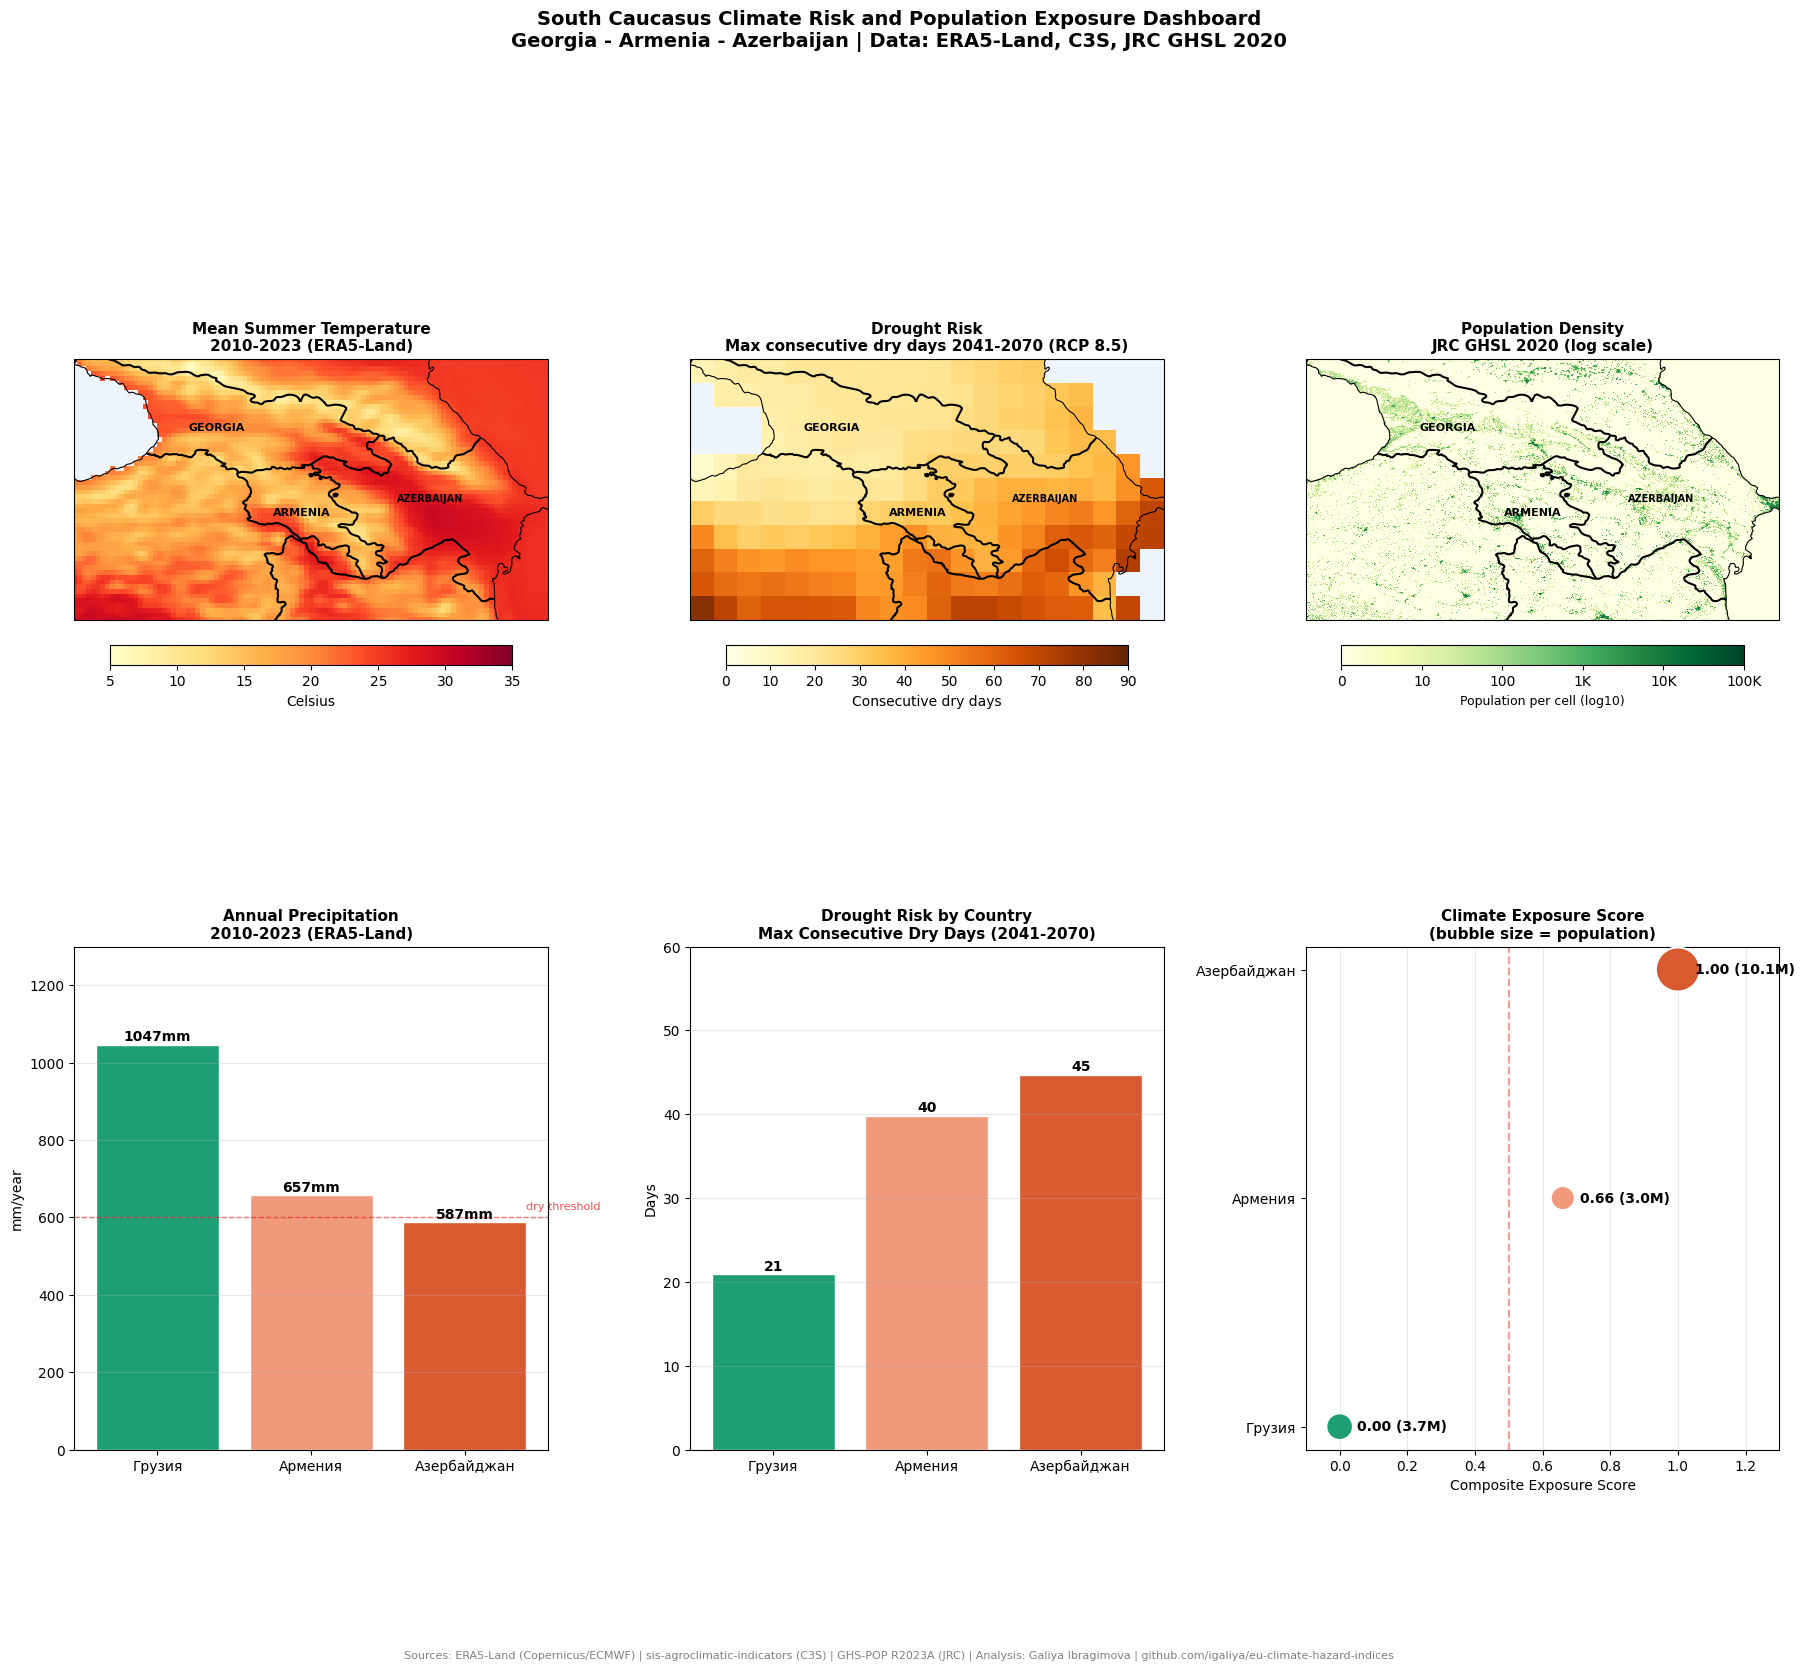

Final dashboard saved!


In [49]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rasterio
from rasterio.windows import from_bounds

fig = plt.figure(figsize=(22, 16))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.3)
extent = [40, 50, 38, 43.5]

# КАРТА 1: ТЕМПЕРАТУРА
ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
t2m_mean = t2m2.mean(dim='valid_time')
im1 = ax1.pcolormesh(temp2.longitude, temp2.latitude, t2m_mean, transform=ccrs.PlateCarree(), cmap='YlOrRd', vmin=5, vmax=35)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax1.add_feature(cfeature.BORDERS, linewidth=1.5, color='black', zorder=5)
ax1.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax1.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax1.set_extent(extent, crs=ccrs.PlateCarree())
ax1.set_title('Mean Summer Temperature\n2010-2023 (ERA5-Land)', fontsize=11, fontweight='bold')
ax1.text(43.0, 42.0, 'GEORGIA', transform=ccrs.PlateCarree(), fontsize=8, fontweight='bold', color='black', ha='center', zorder=6)
ax1.text(44.8, 40.2, 'ARMENIA', transform=ccrs.PlateCarree(), fontsize=8, fontweight='bold', color='black', ha='center', zorder=6)
ax1.text(47.5, 40.5, 'AZERBAIJAN', transform=ccrs.PlateCarree(), fontsize=7, fontweight='bold', color='black', ha='center', zorder=6)
plt.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.85, label='Celsius')

# КАРТА 2: ЗАСУХА (обновлённая)
ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
im2 = ax2.pcolormesh(drought_caucasus_v2.lon, drought_caucasus_v2.lat, drought_caucasus_v2, transform=ccrs.PlateCarree(), cmap='YlOrBr', vmin=0, vmax=90)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax2.add_feature(cfeature.BORDERS, linewidth=1.5, color='black', zorder=5)
ax2.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax2.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax2.set_extent(extent, crs=ccrs.PlateCarree())
ax2.set_title('Drought Risk\nMax consecutive dry days 2041-2070 (RCP 8.5)', fontsize=11, fontweight='bold')
ax2.text(43.0, 42.0, 'GEORGIA', transform=ccrs.PlateCarree(), fontsize=8, fontweight='bold', color='black', ha='center', zorder=6)
ax2.text(44.8, 40.2, 'ARMENIA', transform=ccrs.PlateCarree(), fontsize=8, fontweight='bold', color='black', ha='center', zorder=6)
ax2.text(47.5, 40.5, 'AZERBAIJAN', transform=ccrs.PlateCarree(), fontsize=7, fontweight='bold', color='black', ha='center', zorder=6)
plt.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.85, label='Consecutive dry days')

# КАРТА 3: НАСЕЛЕНИЕ
ax3 = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())
pop_file = "C:/Users/Galiya/climate_risk_data/population/GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0.tif"
with rasterio.open(pop_file) as src:
    window = from_bounds(40, 38, 50, 43.5, src.transform)
    pop_data = src.read(1, window=window).astype(float)
    pop_data[pop_data < 0] = np.nan
lons = np.linspace(40, 50, pop_data.shape[1])
lats = np.linspace(43.5, 38, pop_data.shape[0])
lon_grid, lat_grid = np.meshgrid(lons, lats)
pop_log = np.log10(pop_data + 1)
im3 = ax3.pcolormesh(lon_grid, lat_grid, pop_log, transform=ccrs.PlateCarree(), cmap='YlGn', vmin=0, vmax=5)
ax3.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax3.add_feature(cfeature.BORDERS, linewidth=1.5, color='black', zorder=5)
ax3.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax3.set_extent(extent, crs=ccrs.PlateCarree())
ax3.set_title('Population Density\nJRC GHSL 2020 (log scale)', fontsize=11, fontweight='bold')
ax3.text(43.0, 42.0, 'GEORGIA', transform=ccrs.PlateCarree(), fontsize=8, fontweight='bold', color='black', ha='center', zorder=6)
ax3.text(44.8, 40.2, 'ARMENIA', transform=ccrs.PlateCarree(), fontsize=8, fontweight='bold', color='black', ha='center', zorder=6)
ax3.text(47.5, 40.5, 'AZERBAIJAN', transform=ccrs.PlateCarree(), fontsize=7, fontweight='bold', color='black', ha='center', zorder=6)
cbar3 = plt.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.85)
cbar3.set_label('Population per cell (log10)', fontsize=9)
cbar3.set_ticks([0, 1, 2, 3, 4, 5])
cbar3.set_ticklabels(['0', '10', '100', '1K', '10K', '100K'])

# ГРАФИК 4: ОСАДКИ
ax4 = fig.add_subplot(gs[1, 0])
colors = ['#1D9E75', '#F0997B', '#D85A30']
countries_list = df['Страна'].tolist()
precip_vals = df['Осадки_мм_год'].tolist()
bars4 = ax4.bar(countries_list, precip_vals, color=colors, edgecolor='white')
ax4.set_ylabel('mm/year', fontsize=10)
ax4.set_title('Annual Precipitation\n2010-2023 (ERA5-Land)', fontsize=11, fontweight='bold')
for bar, val in zip(bars4, precip_vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f'{val:.0f}mm', ha='center', fontsize=10, fontweight='bold')
ax4.set_ylim(0, 1300)
ax4.grid(axis='y', alpha=0.3)
ax4.axhline(y=600, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax4.text(2.4, 620, 'dry threshold', fontsize=8, color='red', alpha=0.7)

# ГРАФИК 5: ЗАСУХА
ax5 = fig.add_subplot(gs[1, 1])
cdds = df['Засуха_CDD_дней'].tolist()
bars5 = ax5.bar(countries_list, cdds, color=colors, edgecolor='white')
ax5.set_ylabel('Days', fontsize=10)
ax5.set_title('Drought Risk by Country\nMax Consecutive Dry Days (2041-2070)', fontsize=11, fontweight='bold')
for bar, val in zip(bars5, cdds):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.0f}', ha='center', fontsize=10, fontweight='bold')
ax5.set_ylim(0, 60)
ax5.grid(axis='y', alpha=0.3)

# ГРАФИК 6: BUBBLE CHART
ax6 = fig.add_subplot(gs[1, 2])
scores = df['exposure_score'].tolist()
pop_millions = df['Население_млн'].tolist()
ax6.scatter(scores, countries_list, s=[p*100 for p in pop_millions], color=colors, edgecolor='white', linewidth=1.5, zorder=3)
ax6.set_xlim(-0.1, 1.3)
ax6.set_xlabel('Composite Exposure Score', fontsize=10)
ax6.set_title('Climate Exposure Score\n(bubble size = population)', fontsize=11, fontweight='bold')
for i, (score, country, pop) in enumerate(zip(scores, countries_list, pop_millions)):
    ax6.text(score + 0.05, i, f'{score:.2f} ({pop}M)', va='center', fontsize=10, fontweight='bold')
ax6.grid(axis='x', alpha=0.3)
ax6.axvline(x=0.5, color='red', linestyle='--', alpha=0.4)

fig.suptitle('South Caucasus Climate Risk and Population Exposure Dashboard\nGeorgia - Armenia - Azerbaijan | Data: ERA5-Land, C3S, JRC GHSL 2020', fontsize=14, fontweight='bold', y=1.01)
fig.text(0.5, -0.02, 'Sources: ERA5-Land (Copernicus/ECMWF) | sis-agroclimatic-indicators (C3S) | GHS-POP R2023A (JRC) | Analysis: Galiya Ibragimova | github.com/igaliya/eu-climate-hazard-indices', ha='center', fontsize=8, color='gray')

plt.savefig('C:/Users/Galiya/south_caucasus_climate_dashboard_final.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Final dashboard saved!")

C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
C:\Users\Galiya\climate_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


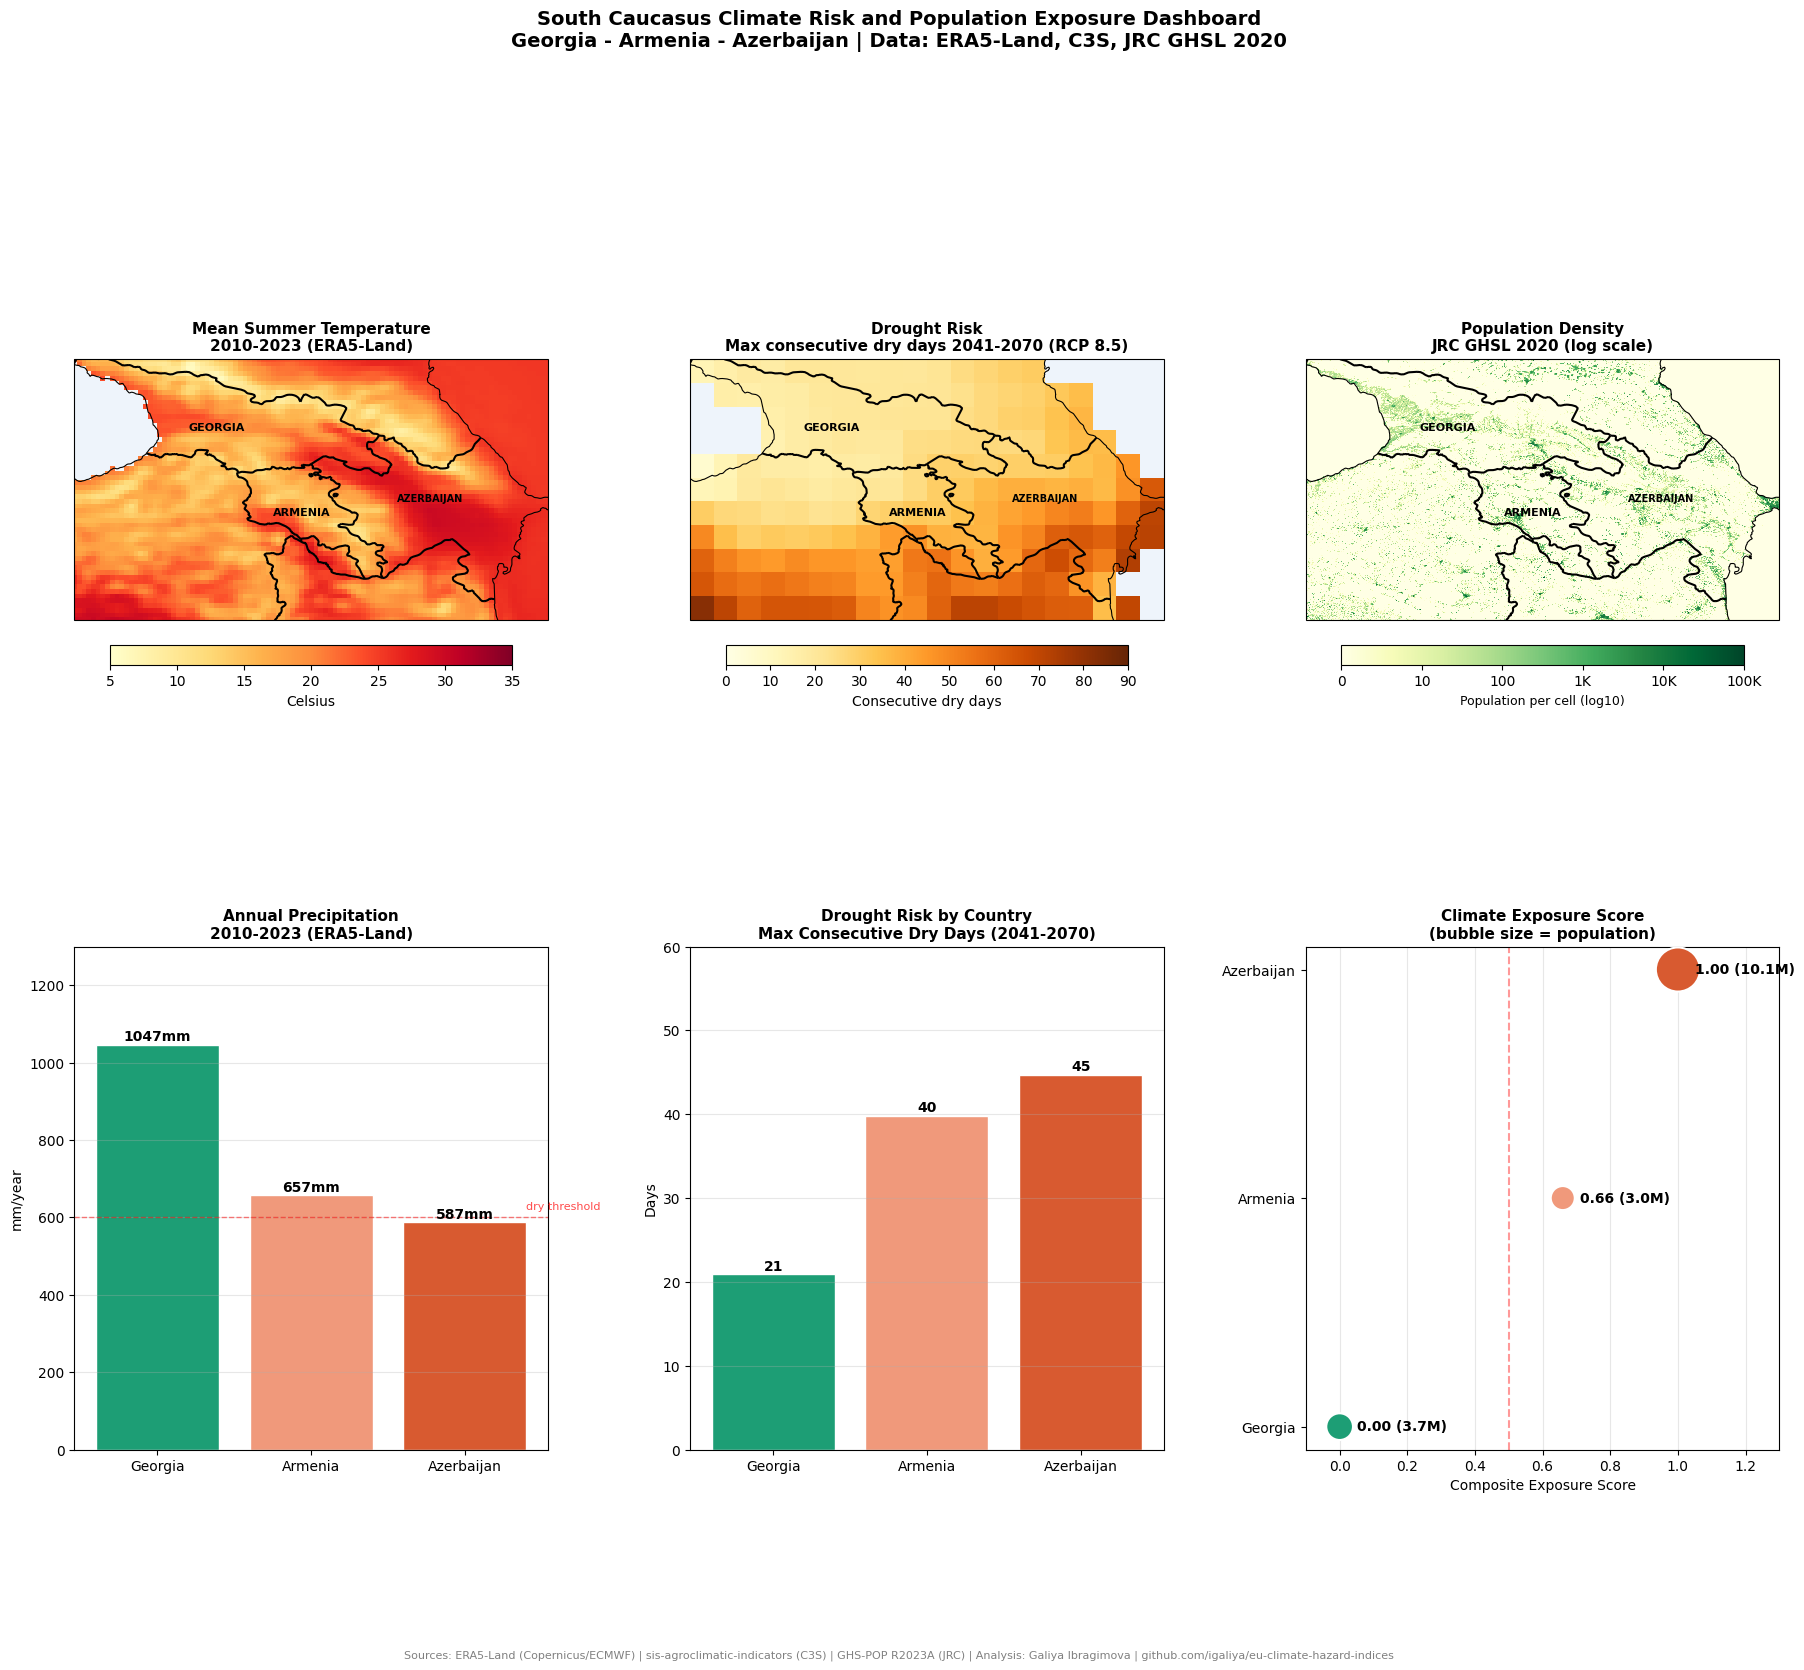

Final dashboard saved!


In [50]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rasterio
from rasterio.windows import from_bounds
import pandas as pd

# ФИНАЛЬНЫЙ DATAFRAME с английскими названиями
df = pd.DataFrame({
    'Country': ['Georgia', 'Armenia', 'Azerbaijan'],
    'Population_mln': [3.7, 3.0, 10.1],
    'Density_per_km2': [53, 101, 120],
    'Summer_temp_C': [18.0, 19.4, 23.0],
    'Precip_mm_year': [1047, 657, 587],
    'Drought_CDD_days': [20.9, 39.8, 44.7],
})

df['temp_norm'] = (df['Summer_temp_C'] - df['Summer_temp_C'].min()) / (df['Summer_temp_C'].max() - df['Summer_temp_C'].min())
df['precip_norm'] = 1 - ((df['Precip_mm_year'] - df['Precip_mm_year'].min()) / (df['Precip_mm_year'].max() - df['Precip_mm_year'].min()))
df['drought_norm'] = (df['Drought_CDD_days'] - df['Drought_CDD_days'].min()) / (df['Drought_CDD_days'].max() - df['Drought_CDD_days'].min())
df['density_norm'] = (df['Density_per_km2'] - df['Density_per_km2'].min()) / (df['Density_per_km2'].max() - df['Density_per_km2'].min())
df['exposure_score'] = (df['temp_norm'] + df['precip_norm'] + df['drought_norm'] + df['density_norm']) / 4

fig = plt.figure(figsize=(22, 16))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.3)
extent = [40, 50, 38, 43.5]
colors = ['#1D9E75', '#F0997B', '#D85A30']
countries_list = df['Country'].tolist()

# КАРТА 1: ТЕМПЕРАТУРА
ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
t2m_mean = t2m2.mean(dim='valid_time')
im1 = ax1.pcolormesh(temp2.longitude, temp2.latitude, t2m_mean, transform=ccrs.PlateCarree(), cmap='YlOrRd', vmin=5, vmax=35)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax1.add_feature(cfeature.BORDERS, linewidth=1.5, color='black', zorder=5)
ax1.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax1.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax1.set_extent(extent, crs=ccrs.PlateCarree())
ax1.set_title('Mean Summer Temperature\n2010-2023 (ERA5-Land)', fontsize=11, fontweight='bold')
ax1.text(43.0, 42.0, 'GEORGIA', transform=ccrs.PlateCarree(), fontsize=8, fontweight='bold', color='black', ha='center', zorder=6)
ax1.text(44.8, 40.2, 'ARMENIA', transform=ccrs.PlateCarree(), fontsize=8, fontweight='bold', color='black', ha='center', zorder=6)
ax1.text(47.5, 40.5, 'AZERBAIJAN', transform=ccrs.PlateCarree(), fontsize=7, fontweight='bold', color='black', ha='center', zorder=6)
plt.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.85, label='Celsius')

# КАРТА 2: ЗАСУХА
ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
im2 = ax2.pcolormesh(drought_caucasus_v2.lon, drought_caucasus_v2.lat, drought_caucasus_v2, transform=ccrs.PlateCarree(), cmap='YlOrBr', vmin=0, vmax=90)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax2.add_feature(cfeature.BORDERS, linewidth=1.5, color='black', zorder=5)
ax2.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax2.add_feature(cfeature.LAND, color='#F5F5F5', zorder=0)
ax2.set_extent(extent, crs=ccrs.PlateCarree())
ax2.set_title('Drought Risk\nMax consecutive dry days 2041-2070 (RCP 8.5)', fontsize=11, fontweight='bold')
ax2.text(43.0, 42.0, 'GEORGIA', transform=ccrs.PlateCarree(), fontsize=8, fontweight='bold', color='black', ha='center', zorder=6)
ax2.text(44.8, 40.2, 'ARMENIA', transform=ccrs.PlateCarree(), fontsize=8, fontweight='bold', color='black', ha='center', zorder=6)
ax2.text(47.5, 40.5, 'AZERBAIJAN', transform=ccrs.PlateCarree(), fontsize=7, fontweight='bold', color='black', ha='center', zorder=6)
plt.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.85, label='Consecutive dry days')

# КАРТА 3: НАСЕЛЕНИЕ
ax3 = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())
pop_file = "C:/Users/Galiya/climate_risk_data/population/GHS_POP_E2020_GLOBE_R2023A_4326_30ss_V1_0.tif"
with rasterio.open(pop_file) as src:
    window = from_bounds(40, 38, 50, 43.5, src.transform)
    pop_data = src.read(1, window=window).astype(float)
    pop_data[pop_data < 0] = np.nan
lons = np.linspace(40, 50, pop_data.shape[1])
lats = np.linspace(43.5, 38, pop_data.shape[0])
lon_grid, lat_grid = np.meshgrid(lons, lats)
pop_log = np.log10(pop_data + 1)
im3 = ax3.pcolormesh(lon_grid, lat_grid, pop_log, transform=ccrs.PlateCarree(), cmap='YlGn', vmin=0, vmax=5)
ax3.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax3.add_feature(cfeature.BORDERS, linewidth=1.5, color='black', zorder=5)
ax3.add_feature(cfeature.OCEAN, color='#EEF4FB', zorder=0)
ax3.set_extent(extent, crs=ccrs.PlateCarree())
ax3.set_title('Population Density\nJRC GHSL 2020 (log scale)', fontsize=11, fontweight='bold')
ax3.text(43.0, 42.0, 'GEORGIA', transform=ccrs.PlateCarree(), fontsize=8, fontweight='bold', color='black', ha='center', zorder=6)
ax3.text(44.8, 40.2, 'ARMENIA', transform=ccrs.PlateCarree(), fontsize=8, fontweight='bold', color='black', ha='center', zorder=6)
ax3.text(47.5, 40.5, 'AZERBAIJAN', transform=ccrs.PlateCarree(), fontsize=7, fontweight='bold', color='black', ha='center', zorder=6)
cbar3 = plt.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.85)
cbar3.set_label('Population per cell (log10)', fontsize=9)
cbar3.set_ticks([0, 1, 2, 3, 4, 5])
cbar3.set_ticklabels(['0', '10', '100', '1K', '10K', '100K'])

# ГРАФИК 4: ОСАДКИ
ax4 = fig.add_subplot(gs[1, 0])
precip_vals = df['Precip_mm_year'].tolist()
bars4 = ax4.bar(countries_list, precip_vals, color=colors, edgecolor='white')
ax4.set_ylabel('mm/year', fontsize=10)
ax4.set_title('Annual Precipitation\n2010-2023 (ERA5-Land)', fontsize=11, fontweight='bold')
for bar, val in zip(bars4, precip_vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f'{val:.0f}mm', ha='center', fontsize=10, fontweight='bold')
ax4.set_ylim(0, 1300)
ax4.grid(axis='y', alpha=0.3)
ax4.axhline(y=600, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax4.text(2.4, 620, 'dry threshold', fontsize=8, color='red', alpha=0.7)

# ГРАФИК 5: ЗАСУХА
ax5 = fig.add_subplot(gs[1, 1])
cdds = df['Drought_CDD_days'].tolist()
bars5 = ax5.bar(countries_list, cdds, color=colors, edgecolor='white')
ax5.set_ylabel('Days', fontsize=10)
ax5.set_title('Drought Risk by Country\nMax Consecutive Dry Days (2041-2070)', fontsize=11, fontweight='bold')
for bar, val in zip(bars5, cdds):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.0f}', ha='center', fontsize=10, fontweight='bold')
ax5.set_ylim(0, 60)
ax5.grid(axis='y', alpha=0.3)

# ГРАФИК 6: BUBBLE CHART
ax6 = fig.add_subplot(gs[1, 2])
scores = df['exposure_score'].tolist()
pop_millions = df['Population_mln'].tolist()
ax6.scatter(scores, countries_list, s=[p*100 for p in pop_millions], color=colors, edgecolor='white', linewidth=1.5, zorder=3)
ax6.set_xlim(-0.1, 1.3)
ax6.set_xlabel('Composite Exposure Score', fontsize=10)
ax6.set_title('Climate Exposure Score\n(bubble size = population)', fontsize=11, fontweight='bold')
for i, (score, country, pop) in enumerate(zip(scores, countries_list, pop_millions)):
    ax6.text(score + 0.05, i, f'{score:.2f} ({pop}M)', va='center', fontsize=10, fontweight='bold')
ax6.grid(axis='x', alpha=0.3)
ax6.axvline(x=0.5, color='red', linestyle='--', alpha=0.4)

fig.suptitle('South Caucasus Climate Risk and Population Exposure Dashboard\nGeorgia - Armenia - Azerbaijan | Data: ERA5-Land, C3S, JRC GHSL 2020', fontsize=14, fontweight='bold', y=1.01)
fig.text(0.5, -0.02, 'Sources: ERA5-Land (Copernicus/ECMWF) | sis-agroclimatic-indicators (C3S) | GHS-POP R2023A (JRC) | Analysis: Galiya Ibragimova | github.com/igaliya/eu-climate-hazard-indices', ha='center', fontsize=8, color='gray')

plt.savefig('C:/Users/Galiya/south_caucasus_climate_dashboard_final.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Final dashboard saved!")